In [1]:
import tensorflow as tf 

gpus = tf.config.list_physical_devices("GPU")

print(gpus)

2025-02-22 09:58:41.266401: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-22 09:58:41.292155: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-22 09:58:41.292172: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-22 09:58:41.292918: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-22 09:58:41.297597: I tensorflow/core/platform/cpu_feature_guar

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
import sys
sys.path.append('/home/alumnos/mburgosc/tfg/egm_reconstruction/Code/tools_')

import tools

In [4]:
import sys, os


from scipy.io import loadmat
import numpy as np
from random import randint
import matplotlib.pyplot as plt
from itertools import product
from numpy.random import default_rng
import scipy.io
import h5py
from scipy import signal as sigproc
from scipy.interpolate import interp1d
from math import floor
from scipy import signal
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
import tensorflow as tf
import random
import math
from sklearn.metrics import mean_squared_error
from fastdtw import fastdtw
import time
import keras
from keras import models, layers
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from tensorflow.keras import datasets, layers, models, losses, Model
from generators import *
from numpy import reshape
import matplotlib.image
from scipy.io import savemat
#from plots import *
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from datetime import time


In [5]:
from tools import load_egms_df
data_short_dir = "/home/alumnos/mburgosc/tfg/egm_reconstruction/Data_short"
egms_all_models = load_egms_df(data_short_dir)

data ['Simulation_01_210209_001_002', 'LA_RSPV_CAF_150115', 'Simulation_01_200428_001_001', 'Simulation_01_201223_001_002', 'Simulation_01_190619_001_004', 'Simulation_01_190502_001_004', 'RA_RAFW_140807', 'RA_RAA_141230', 'Simulation_01_200316_001_  1', 'TwoRotors_181219', 'RA_RAFW_SAF_140730', 'Simulation_01_200212_001_  4']


In [6]:
print(egms_all_models)

                              id  \
0   Simulation_01_210209_001_002   
1             LA_RSPV_CAF_150115   
2   Simulation_01_200428_001_001   
3   Simulation_01_201223_001_002   
4   Simulation_01_190619_001_004   
5   Simulation_01_190502_001_004   
6                 RA_RAFW_140807   
7                  RA_RAA_141230   
8   Simulation_01_200316_001_  1   
9               TwoRotors_181219   
10            RA_RAFW_SAF_140730   
11  Simulation_01_200212_001_  4   

                                            AF_signal  
0   [[9.479828179102282e-14, 0.04080228461795585, ...  
1   [[7.387776530722087, 9.094867906767199, 10.800...  
2   [[0.8807414426522221, 1.015404814148348, 0.963...  
3   [[4.24492593645743, 4.6424979299912765, 5.0315...  
4   [[-50.648764509652416, -48.25332554580271, -44...  
5   [[-61.093924858397685, -56.059614688222744, -5...  
6   [[-15.990956008585043, -14.190372868776846, -1...  
7   [[-1.5399639907851848, -1.421404688195314, -1....  
8   [[2.593443248791235, 2.

In [7]:
egms_values = egms_all_models["AF_signal"].tolist()
print(egms_values[0].shape)
print(len(egms_values))


(2048, 1500)
12


In [8]:
import random
from tools import ECG_filtering  #NO ESTA ENCONTRANDO LA FUNCIÓN ASIQUE LA PEGO A MANO
from tools import *

def ECG_filtering(signal, fs, order = 2, f_low=3, f_high=60):
    """
    Frequency filtering of ECG-EGM.
    SR model: low-pass filtering, 4th-order Butterworth filter.
    FA models: bandpass filtering, 4th-order Butterworth filter.

    Parameters:
        signal (array): signal to process
        fs (int): sampling rate
        f_low (int-float): low cut-off frecuency (default=3Hz)
        f_high (int-float): high cut-off frecuency (default=30Hz)
        model (string): FA model to assess (default: SR)
    Returns:
        proc_ECG_EGM (array): filtered ECG-EGM
    """

    # Remove DC component
    sig_temp = remove_mean(signal)
    #sig_temp = signal

    # Bandpass filtering
    b, a = sigproc.butter(
        order, [f_low / round((fs / 2)), f_high / round((fs / 2))], btype="bandpass"
    )

    proc_ECG_EGM = np.zeros(sig_temp.shape)
    if sig_temp.ndim ==3:
        for i in range(sig_temp.shape[1]):  
            for j in range(sig_temp.shape[2]):  
                #for index in range(sig_temp.shape[0]):
                proc_ECG_EGM[:, i, j] = sigproc.filtfilt(b, a, sig_temp[:, i, j])
    else: 
        for index in range(0, sig_temp.shape[0]):
            proc_ECG_EGM[index, :] = sigproc.filtfilt(b, a, sig_temp[index, :])

    return proc_ECG_EGM


egms_filtered_norm = []

for i in range(len(egms_values)):
    
    #ECG FILTERING
    egms = egms_values[i]
    print(egms.shape)
    egms_filt = ECG_filtering(egms.T, 500)
    


    #NORMLIZE EGMS
    high = 1
    low = -1

    mins = np.min(egms_filt, axis=0)
    maxs = np.max(egms_filt, axis=0)
    rng = maxs - mins

    norm_egms = high - (((high - low) * (maxs - egms_filt)) / rng)
    
    norm_egms = norm_egms.T #para que queden otra vez (2048 x samples of time)
    egms_filtered_norm.append(norm_egms)



(2048, 1500)
(2048, 2499)
(2048, 1301)
(2048, 1500)
(2048, 4000)
(2048, 4000)
(2048, 2000)
(2048, 2000)
(2048, 2001)
(2048, 2499)
(2048, 2499)
(2048, 4501)


In [9]:
transfer_matrices = load_transfer(ten_leads=False, bsps_set=False)

In [10]:
#COMPUTING THE FORWARD PROBLEM

# y = A*x --> y: bsps, A: transfer matrix, x: egms
# A =  (3018x2048) --> 3018 nodos en el torso de los 64 electrodos 
#                  --> 2048 electrodos en la auricula 
# x = (2048x1000)  --> 1000 samples of time
# y = (3018x1000)  

A = transfer_matrices[0]

print(A)
print(A[1].shape) #--> matriz de transferencia

bsps_all_models = []
for i in range(len(egms_filtered_norm)):

    y_f = forward_problem(egms_filtered_norm[i], A[0]) # bsps
    bsps_all_models.append(y_f)


print(bsps_all_models[0].shape)

(array([[ 7.69965054e-05,  7.34290114e-05,  5.55983500e-05, ...,
        -4.30014225e-04,  3.20904568e-03,  2.03465098e-03],
       [-1.46424028e-04, -1.47995566e-04, -6.64696334e-05, ...,
         6.82507351e-04, -1.64109737e-03, -7.97225589e-04],
       [-1.17874811e-04, -1.11635205e-04, -5.44792074e-05, ...,
        -2.10877594e-04, -1.42770170e-03, -1.17830147e-03],
       ...,
       [-4.31684863e-05, -3.11358531e-05, -1.69536380e-05, ...,
        -1.81270509e-04, -4.25855593e-05, -2.64389011e-04],
       [-9.15845321e-05, -8.35069368e-05, -4.04402041e-05, ...,
        -4.26394139e-04, -9.76937571e-04, -9.75087733e-04],
       [-5.75701441e-05, -4.84485410e-05, -3.20869635e-05, ...,
         2.06745799e-04, -1.04379968e-03, -9.80077168e-04]]), array([[ 552],
       [3422],
       [2994],
       [  46],
       [ 971],
       [2982],
       [ 520],
       [ 522],
       [3502],
       [3188],
       [ 674],
       [ 472],
       [2694],
       [2641],
       [  18],
       [  40],
 

In [11]:
#nos quedamos con 64 nodos para los bsps como chaqueta
bsps_64_all_models = []
for i in range(len(bsps_all_models)):

    bsps_64 = bsps_all_models[i][A[1].ravel(),:]
    print(bsps_64.shape)
    bsps_64_all_models.append(bsps_64)

    
print()
print(bsps_64_all_models[0].shape)
print(bsps_64_all_models[0][0,:].shape)

(64, 1500)
(64, 2499)
(64, 1301)
(64, 1500)
(64, 4000)
(64, 4000)
(64, 2000)
(64, 2000)
(64, 2001)
(64, 2499)
(64, 2499)
(64, 4501)

(64, 1500)
(1500,)


Text(0, 0.5, 'Amplitude')

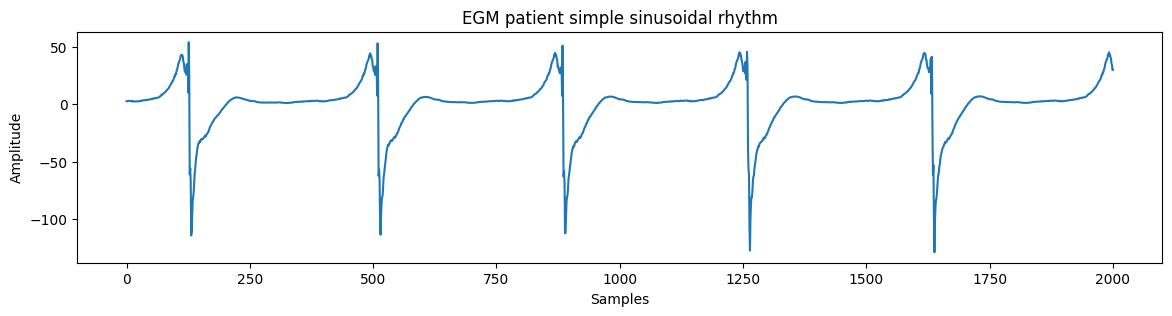

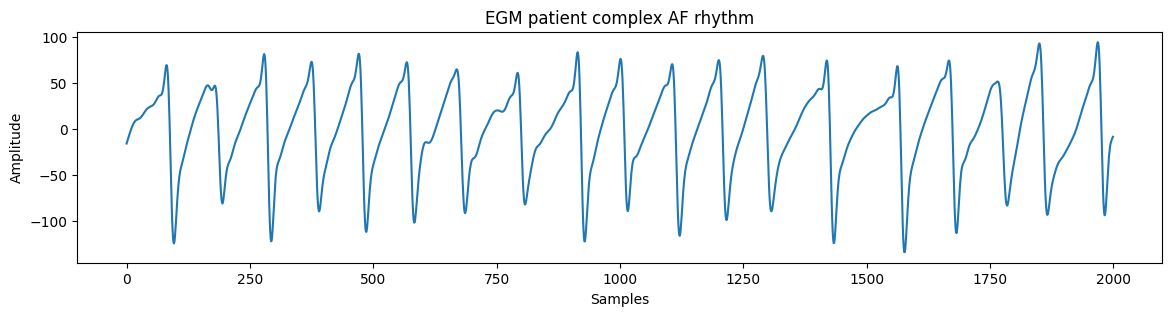

In [12]:
egms_val_s = egms_values[8]
egms_val_c = egms_values[6]

plt.figure(figsize=(14, 3))
plt.plot(egms_val_s[0,:])
plt.title("EGM patient simple sinusoidal rhythm")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.figure(figsize=(14, 3))
plt.plot(egms_val_c[0,:])
plt.title("EGM patient complex AF rhythm")
plt.xlabel("Samples")
plt.ylabel("Amplitude")


Text(0, 0.5, 'Amplitude')

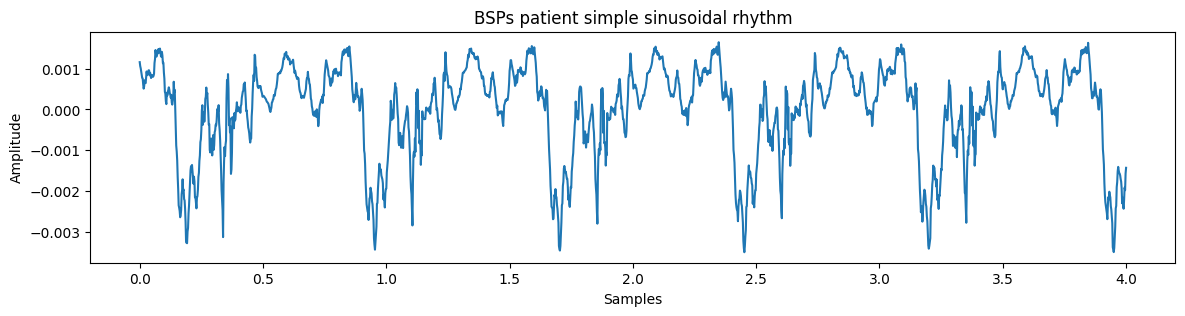

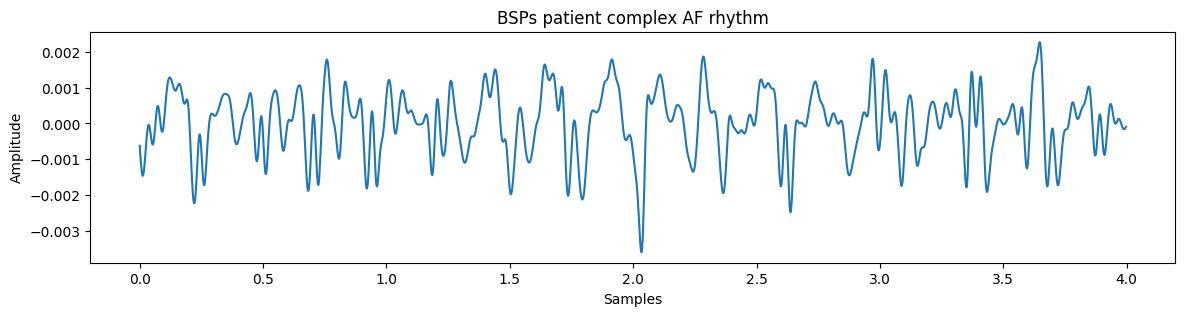

In [13]:
bsps_64_all_models_s = bsps_64_all_models[8]
signal_s = bsps_64_all_models_s[0,:]-np.mean(bsps_64_all_models_s[0,:])

bsps_64_all_models_c = bsps_64_all_models[6]
signal_c = bsps_64_all_models_c[0,:]-np.mean(bsps_64_all_models_c[0,:])

fs = 500
t_s = np.arange(len(signal_s))/fs
t_c = np.arange(len(signal_c))/fs

plt.figure(figsize=(14, 3))
plt.plot(t_s, signal_s)
plt.title("BSPs patient simple sinusoidal rhythm")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.figure(figsize=(14, 3))
plt.plot(t_c, signal_c)
plt.title("BSPs patient complex AF rhythm")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

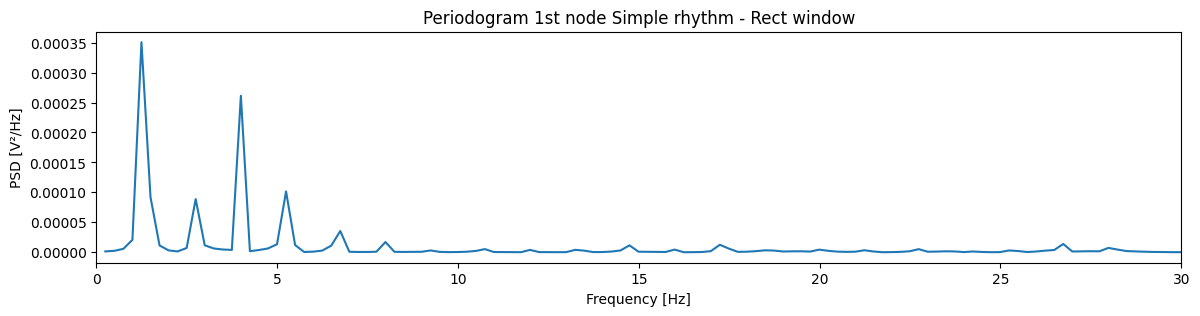

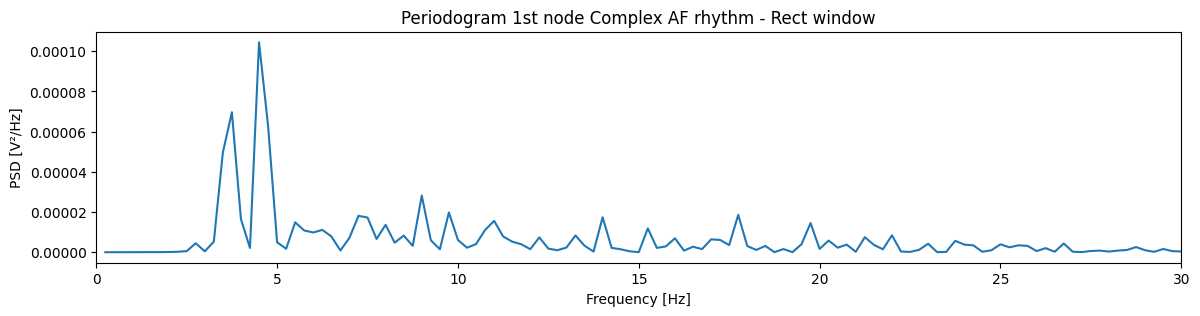

In [14]:
#PERIODOGRAMA A SECAS FFT --> SIN VENTANA (O RECTANGULAR)

fs = 500  
signals = [signal_s, signal_c]
signals_name = ["Simple rhythm", "Complex AF rhythm"]

for signal, signal_name in zip(signals, signals_name):
    N = len(signal)
    window = np.ones(N)
    windowed_signal = (signal) * window

    fft_signal = np.fft.fft(windowed_signal)
    frequencies = np.fft.fftfreq(N, d=1/fs)

    # Calcular el periodograma
    Pxx = (np.abs(fft_signal)**2) / N 
    positive_freqs = frequencies[:N//2]
    positive_Pxx = Pxx[:N//2]

    # Filtrar frecuencias mayores que 0 para evitar log(0)
    mask = positive_freqs > 0  
    positive_freqs = positive_freqs[mask] 
    positive_Pxx = positive_Pxx[mask] 

    plt.figure(figsize=(14, 3))
    plt.plot(positive_freqs, positive_Pxx) 
    plt.xlim(0,30)
    plt.title(f"Periodogram 1st node {signal_name} - Rect window")
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("PSD [V²/Hz]")
    plt.show()

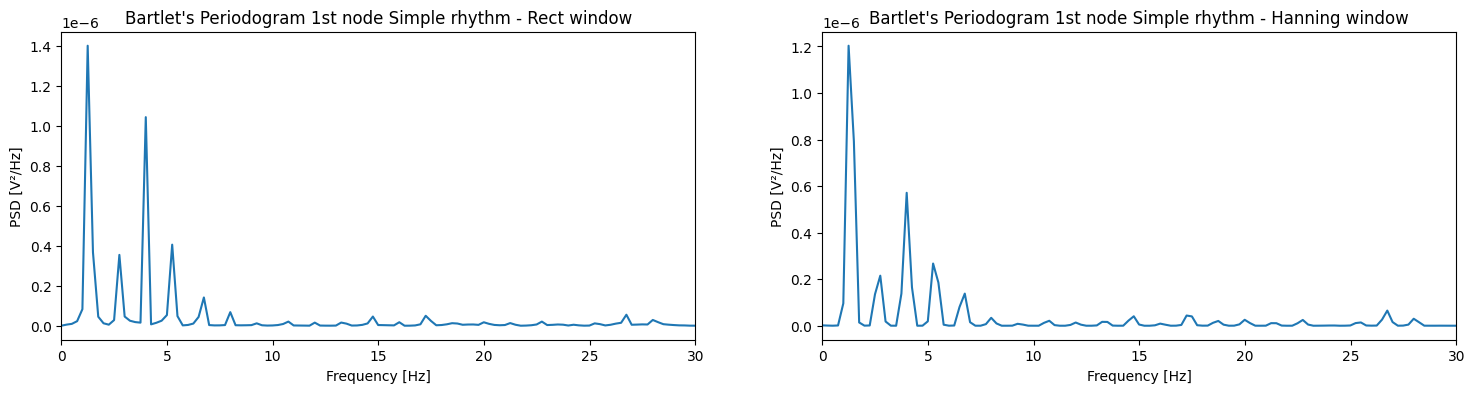

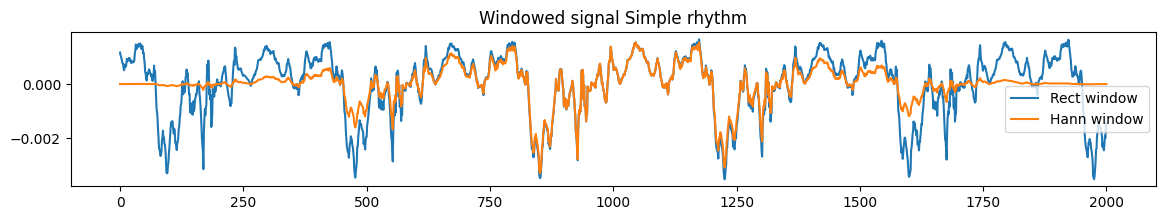

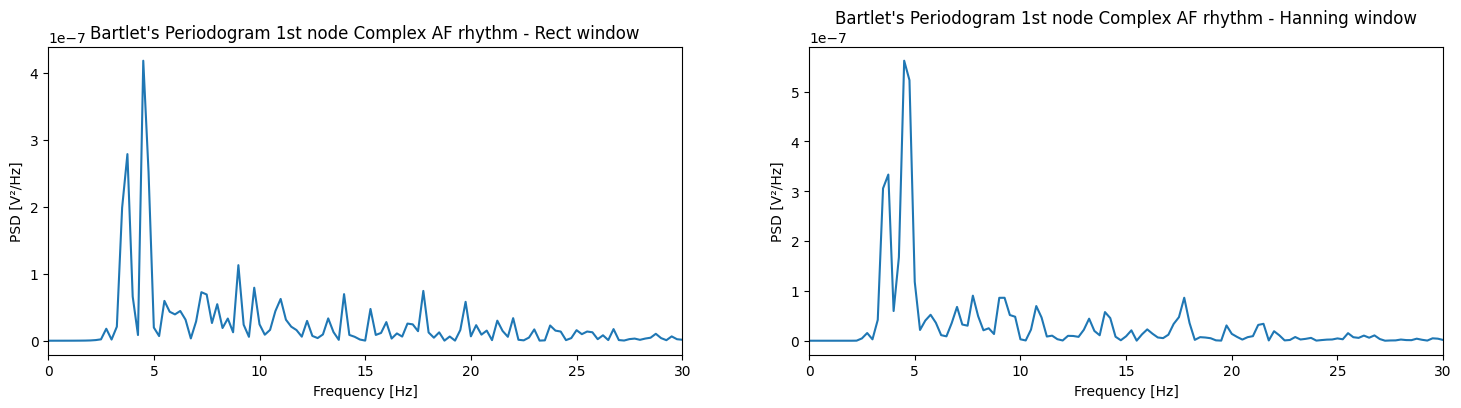

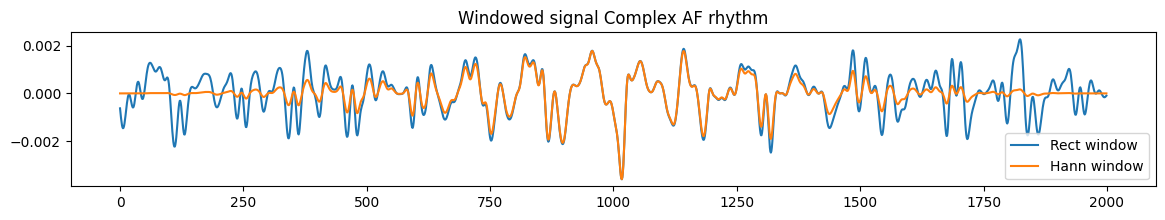

In [15]:
#PERIODOGRAMA Welch --> BARTLETT PERIODOGRAM
from scipy.signal import welch

 

for signal, signal_name in zip(signals, signals_name):

    N = len(signal)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 4))  

    window_r = np.ones(N)
    window_hann = np.hanning(N)
    windowed_signal_r = signal * window_r
    windowed_signal_hann = signal * window_hann

    plt.figure(figsize=(14, 2))
    plt.plot(windowed_signal_r, label="Rect window")
    plt.plot(windowed_signal_hann, label="Hann window")
    plt.title(f"Windowed signal {signal_name}")
    plt.legend()


    f, p = welch(signal, fs=500, window='boxcar', nperseg=len(signal), noverlap=0, nfft=len(signal))
    f, p_h = welch(signal, fs=500, window='hann', nperseg=len(signal), noverlap=0, nfft=len(signal))

  
    ax1.plot(f, p) 
    ax1.set_xlim(0,30)
    ax1.set_title(f"Bartlet's Periodogram 1st node {signal_name} - Rect window")
    ax1.set_xlabel("Frequency [Hz]")
    ax1.set_ylabel("PSD [V²/Hz]")



  
    ax2.plot(f, p_h) 
    ax2.set_xlim(0,30)
    ax2.set_title(f"Bartlet's Periodogram 1st node {signal_name} - Hanning window")
    ax2.set_xlabel("Frequency [Hz]")
    ax2.set_ylabel("PSD [V²/Hz]")
  


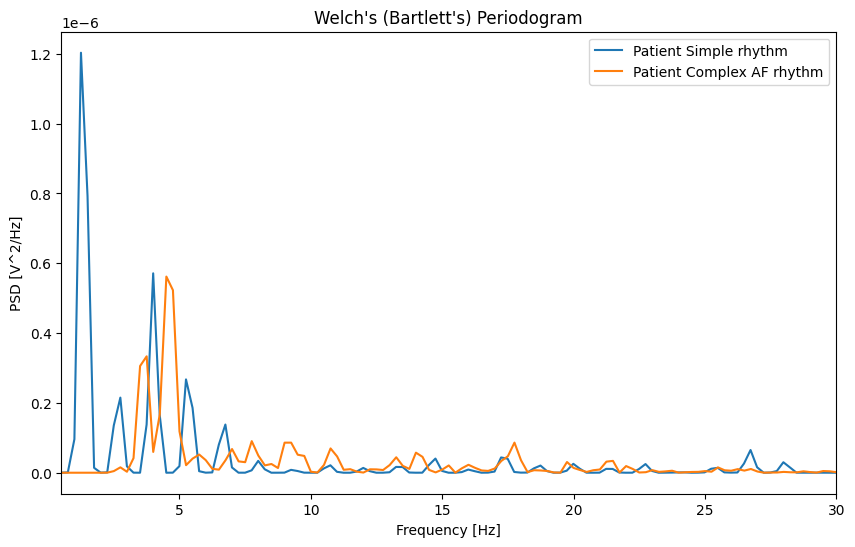

In [16]:
plt.figure(figsize=(10, 6))

for signal, signal_name in zip(signals, signals_name):
    nperseg = len(signal)
    freq, psd = welch(signal, fs=500, nperseg=nperseg, noverlap=0, nfft=None)

    plt.plot(freq, psd, label=f'Patient {signal_name}')

plt.title("Welch's (Bartlett's) Periodogram")
plt.xlabel("Frequency [Hz]")
plt.xlim(0.5, 30) 
plt.ylabel("PSD [V^2/Hz]")
plt.legend()  
   
plt.show()

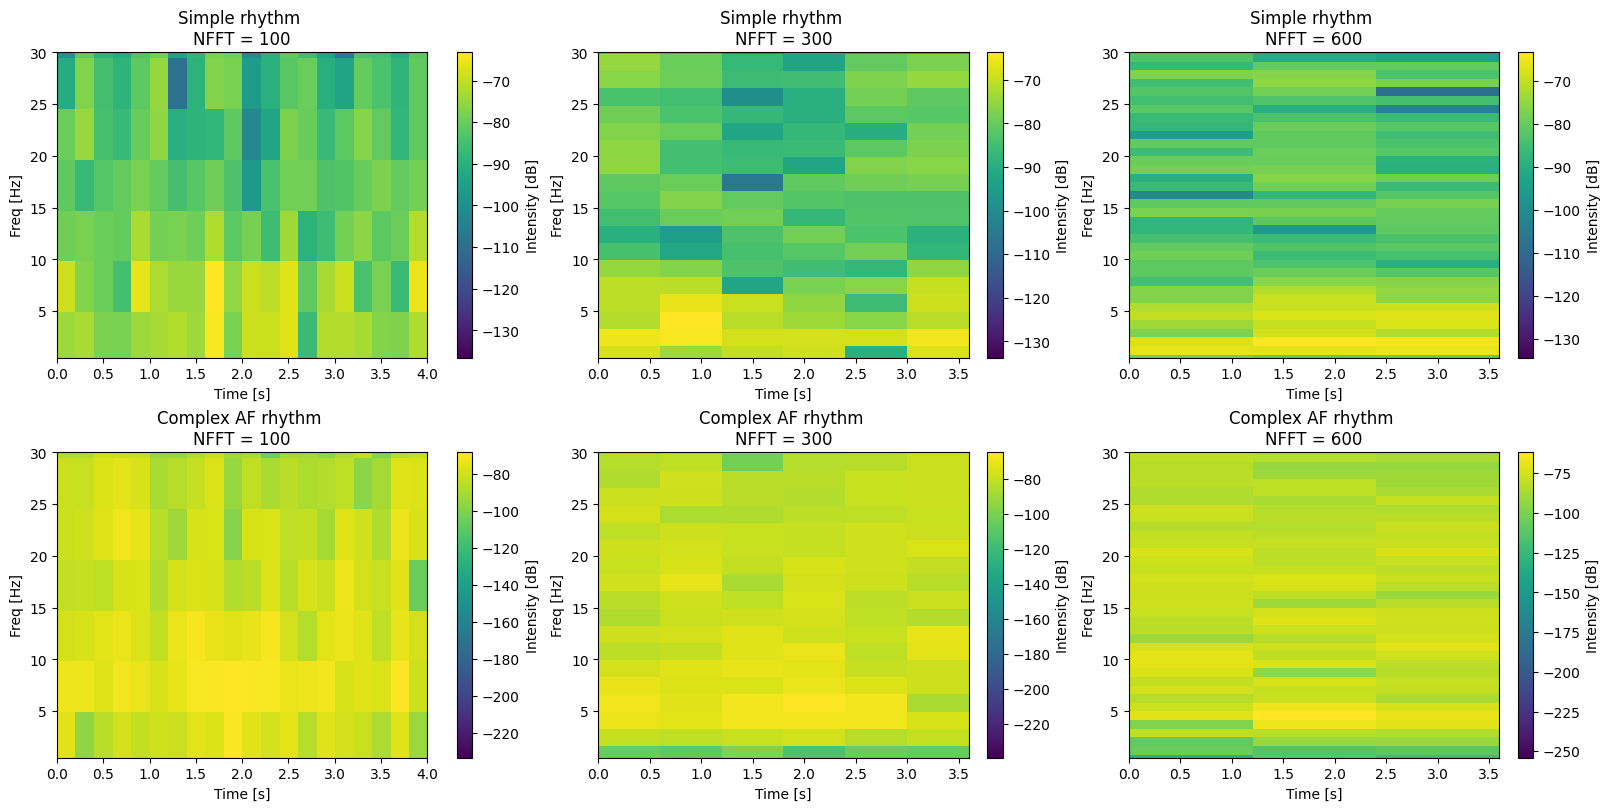

In [17]:



nffts = [100, 300, 600]

fig, axarr = plt.subplots(nrows=len(signals), ncols=len(nffts), figsize=(16, 8), constrained_layout=True)

for row, (signal, signal_name) in enumerate(zip(signals, signals_name)):  
    for col, (nfft, ax) in enumerate(zip(nffts, axarr[row])):  
        Pxx, freqs, bins, im = ax.specgram(signal, Fs=500, NFFT=nfft, 
                                           noverlap=0, window=np.hanning(nfft), cmap='viridis')

        ax.set_title(f"{signal_name} \nNFFT = {nfft}")
        ax.set_xlabel("Time [s]")
        ax.set_ylim(0.5, 30)
        ax.set_ylabel("Freq [Hz]")

        fig.colorbar(im, ax=ax, label='Intensity [dB]')  # Agrega colorbar para cada subplot

plt.show()



<Figure size 1800x400 with 0 Axes>

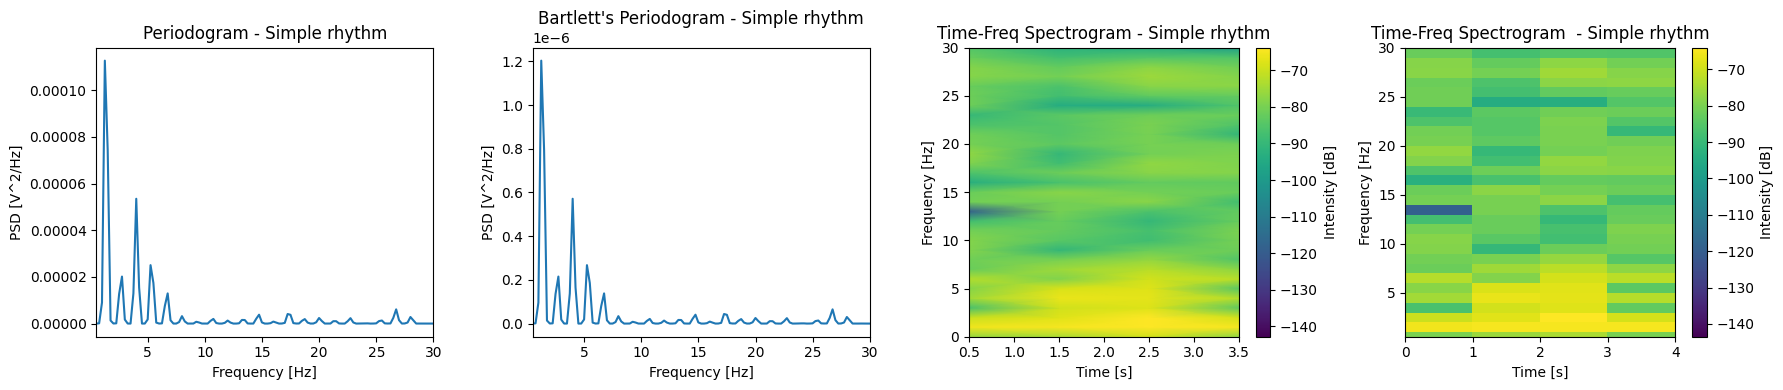

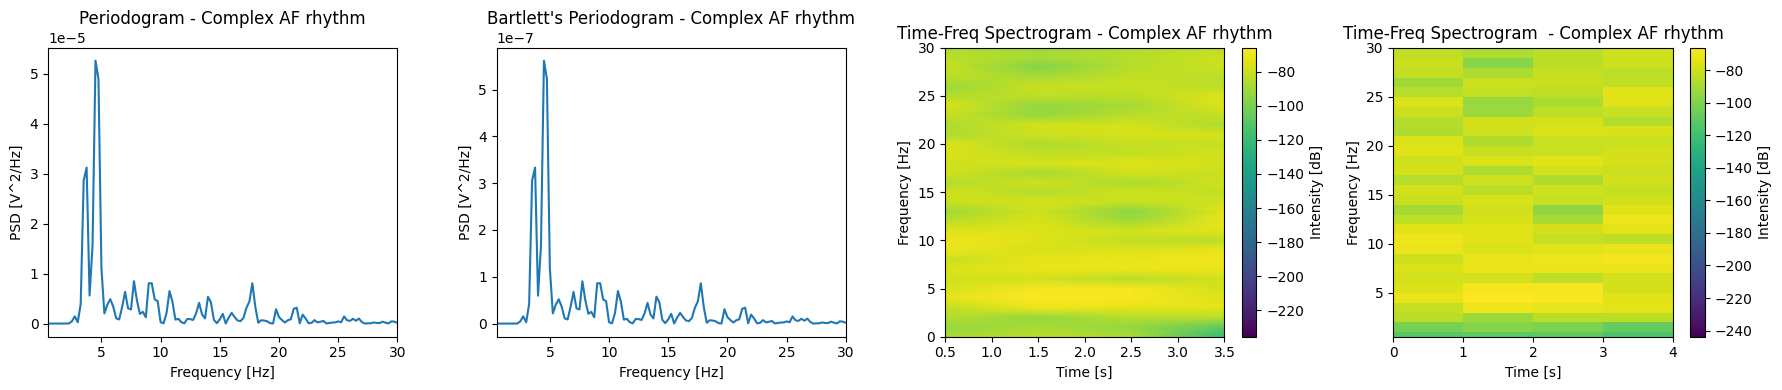

In [18]:
#welch periodoram y sprecrogram para todos los modelos para un solo nodo
from scipy.signal import welch
import scipy.signal as sc

plt.figure(figsize=(18, 4))
for signal, signal_name in zip(signals, signals_name):

    
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(18, 4))  

    # Periodogram
    N = len(signal)
    window = np.hanning(N)
    windowed_signal = (signal) * window

    fft_signal = np.fft.fft(windowed_signal)
    frequencies = np.fft.fftfreq(N, d=1/fs)
    Pxx = (np.abs(fft_signal)**2) / N 

    positive_freqs = frequencies[:N//2]
    positive_Pxx = Pxx[:N//2]

    # Filtrar frecuencias mayores que 0 para evitar log(0)
    mask = positive_freqs > 0  
    positive_freqs = positive_freqs[mask] 
    positive_Pxx = positive_Pxx[mask] 

    ax1.plot(positive_freqs, positive_Pxx) 
    ax1.set_title(f"Periodogram - {signal_name}")
    ax1.set_xlabel("Frequency [Hz]")
    ax1.set_ylabel("PSD [V^2/Hz]")
    ax1.set_xlim(0.5, 30)


    # welch pspectrogram
    freq, psd = welch(signal, fs=500, nperseg=len(signal), noverlap=0, nfft=len(signal), scaling='density')
    ax2.plot(freq, psd)
    ax2.set_title(f"Bartlett's Periodogram - {signal_name}")
    ax2.set_xlabel("Frequency [Hz]")
    ax2.set_ylabel("PSD [V^2/Hz]")
    ax2.set_xlim(0.5, 30)  
    
    # spectrogram a mano
    f, t, Sxx = sc.spectrogram(signal, fs=500, window='hann', nperseg=500, noverlap=0, nfft=None)
    pcm = ax3.pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud')
    ax3.set_ylim(0,30)
    ax3.set_title(f"Time-Freq Spectrogram - {signal_name}")
    ax3.set_xlabel("Time [s]")
    ax3.set_ylabel("Frequency [Hz]")
    #ax3.set_xlim(0, len(signal)/500) 
    fig.colorbar(pcm, ax=ax3, label="Intensity [dB]")

    #func specgram
    ax4.specgram(signal, Fs=500, NFFT=500, noverlap=0, window=np.hanning(500))
    ax4.set_title(f"Time-Freq Spectrogram  - {signal_name}")
    ax4.set_xlabel("Time [s]")
    ax4.set_ylabel("Frequency [Hz]")
    ax4.set_ylim(0.5, 30) 
    fig.colorbar(ax4.images[0], ax=ax4, label='Intensity [dB]')
    #ax4.images[0].set_clim(-100, -50)


    plt.tight_layout()


plt.show()

2001
0.002


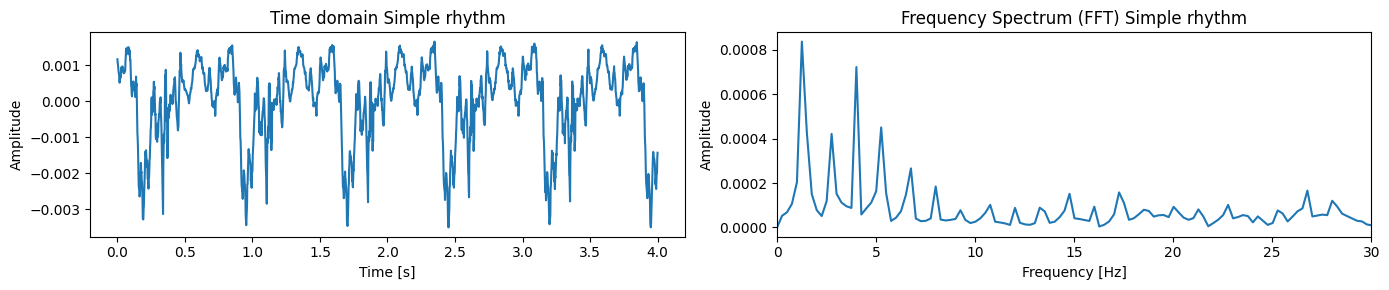

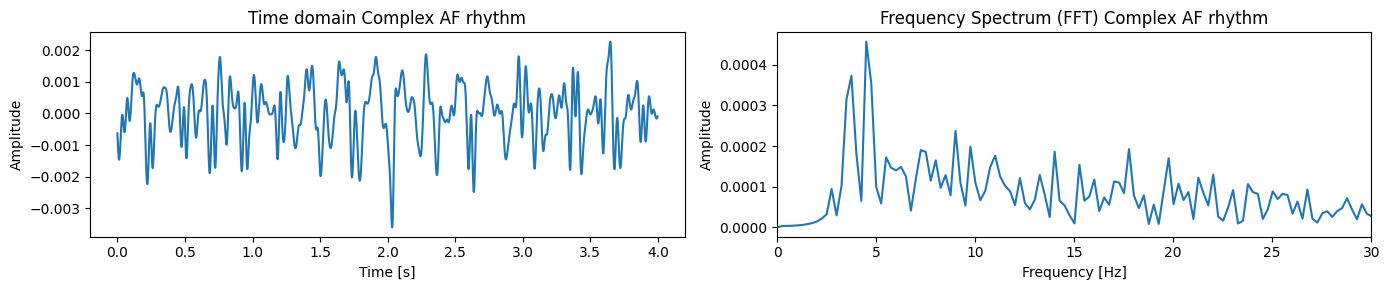

In [19]:
def get_fft_values(y_values, T, N, fs):
    f_values = np.linspace(0.0, 1.0/(2.0*T), N//2)
    fft_values_ = fft(y_values)
    fft_values = 2.0/N * np.abs(fft_values_[0:N//2])
    return f_values, fft_values

from scipy.fftpack import fft
#SENAL CENTRADA EN 0 (EJEY)
print(len(t_s))
dt = t_s[1]-t_s[0]
print(dt)

for signal, signal_name in zip(signals, signals_name):
    N = len(signal)
    fs = 500
    t = np.arange(N)/fs
    f_values1, fft_values1 = get_fft_values(signal, dt, N, fs)
    
    fig, axarr = plt.subplots(nrows=1, ncols=2, figsize=(14,3))
    axarr[0].plot(t, signal)
    axarr[0].set_title(f"Time domain {signal_name}")
    axarr[0].set_xlabel("Time [s]")
    axarr[0].set_ylabel("Amplitude")

    axarr[1].plot(f_values1, fft_values1)
    axarr[1].set_title(f"Frequency Spectrum (FFT) {signal_name}")
    axarr[1].set_xlabel("Frequency [Hz]")
    axarr[1].set_xlim(0,30)
    axarr[1].set_ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

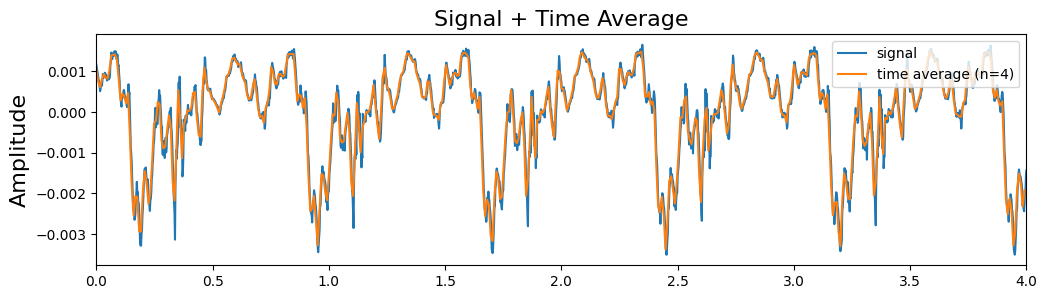

0.002


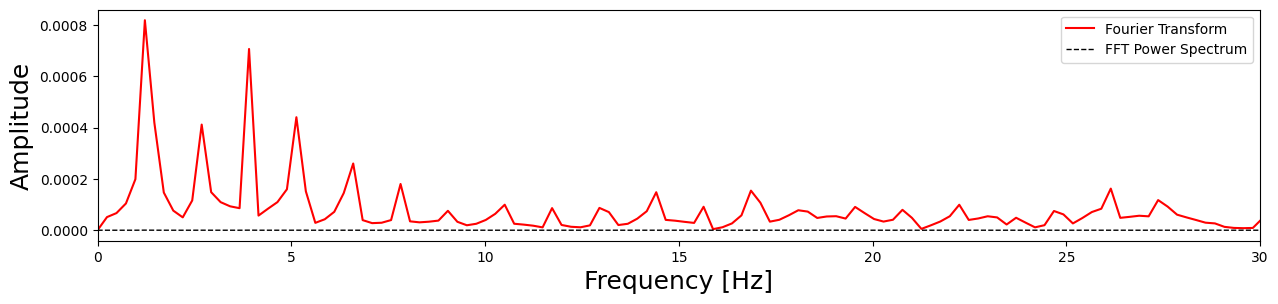

['cgau1', 'cgau2', 'cgau3', 'cgau4', 'cgau5', 'cgau6', 'cgau7', 'cgau8', 'cmor', 'fbsp', 'gaus1', 'gaus2', 'gaus3', 'gaus4', 'gaus5', 'gaus6', 'gaus7', 'gaus8', 'mexh', 'morl', 'shan']


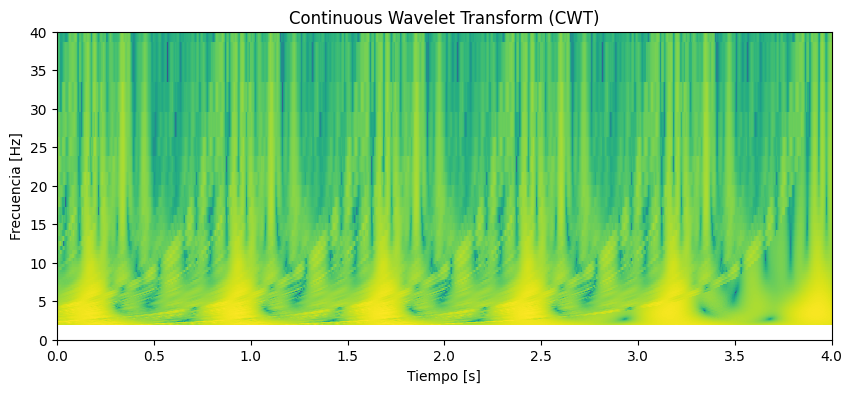

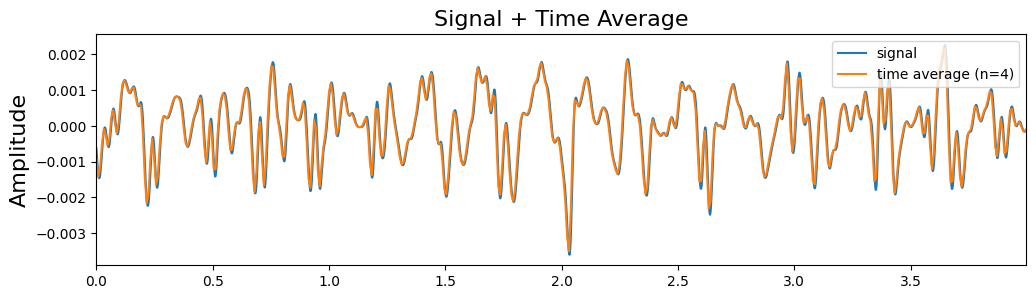

0.002


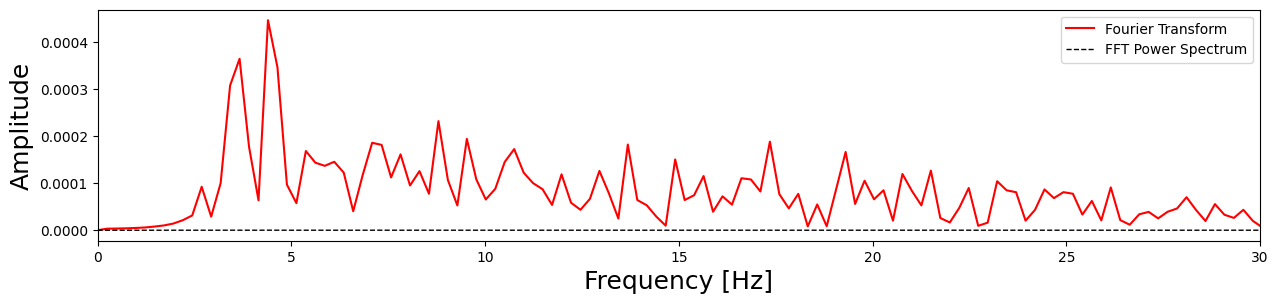

['cgau1', 'cgau2', 'cgau3', 'cgau4', 'cgau5', 'cgau6', 'cgau7', 'cgau8', 'cmor', 'fbsp', 'gaus1', 'gaus2', 'gaus3', 'gaus4', 'gaus5', 'gaus6', 'gaus7', 'gaus8', 'mexh', 'morl', 'shan']


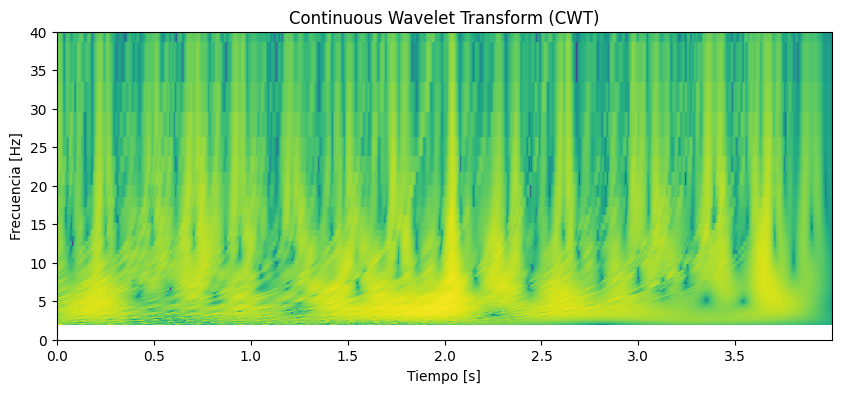

In [20]:
import pywt 

def plot_wavelet(time, signal, scales, 
                 waveletname = 'cmor', 
                 cmap = plt.cm.seismic, 
                 title = 'Wavelet Transform (Power Spectrum) of signal', 
                 ylabel = 'Period (years)', 
                 xlabel = 'Time'):
    
    dt = time[1] - time[0]
    print(dt)
    [coefficients, frequencies] = pywt.cwt(signal, scales, waveletname, dt)
    print(frequencies)
    power = (abs(coefficients)) ** 2
    period = 1. / frequencies
    levels = [0.0625, 0.125, 0.25, 0.5, 1, 2, 4, 8]
    contourlevels = np.log2(levels)
    
    fig, ax = plt.subplots(figsize=(15, 10))
    im = ax.contourf(time, frequencies, np.log2(power), contourlevels, extend='both',cmap=cmap)
    
    ax.set_title(title, fontsize=20)
    ax.set_ylabel(ylabel, fontsize=18)
    ax.set_xlabel(xlabel, fontsize=18)
    
    yticks = 2**np.arange(np.ceil(np.log2(period.min())), np.ceil(np.log2(period.max())))
    ax.set_yticks(np.log2(yticks))
    ax.set_yticklabels(yticks)
    ax.invert_yaxis()
    ylim = ax.get_ylim()
    ax.set_ylim(ylim[0], -1)
    
    cbar_ax = fig.add_axes([0.95, 0.5, 0.03, 0.25])
    fig.colorbar(im, cax=cbar_ax, orientation="vertical")
    plt.show()



def get_ave_values(xvalues, yvalues, n):
    signal_length = len(xvalues)
    if signal_length % n == 0:
        padding_length = 0
    else:
        padding_length = n - signal_length//n % n
    xarr = np.array(xvalues)
    yarr = np.array(yvalues)
    xarr.resize(signal_length//n, n)
    yarr.resize(signal_length//n, n)
    xarr_reshaped = xarr.reshape((-1,n))
    yarr_reshaped = yarr.reshape((-1,n))
    x_ave = xarr_reshaped[:,0]
    y_ave = np.nanmean(yarr_reshaped, axis=1)
    return x_ave, y_ave


def plot_signal_plus_average(ax, time, signal, average_over):
    time_ave, signal_ave = get_ave_values(time, signal, average_over)
    ax.plot(time, signal, label='signal')
    ax.plot(time_ave, signal_ave, label = f'time average (n={average_over})')
    ax.set_xlim([time[0], time[-1]])
    ax.set_ylabel('Amplitude', fontsize=16)
    ax.set_title('Signal + Time Average', fontsize=16)
    ax.legend(loc='upper right')
    plt.show()


def get_fft_values(y_values, T, N, f_s):
    N2 = 2 ** (int(np.log2(N)) + 1) # round up to next highest power of 2
    f_values = np.linspace(0.0, 1.0/(2.0*T), N2//2)
    fft_values_ = fft(y_values)
    fft_values = 2.0/N2 * np.abs(fft_values_[0:N2//2])
    return f_values, fft_values


def plot_fft_plus_power(time, signal):
    dt = time[1] - time[0]
    print(dt)
    N = len(signal)
    fs = 1/dt
    
    
    fig, ax = plt.subplots(figsize=(15, 3))
    variance = np.std(signal)**2
    f_values, fft_values = get_fft_values(signal, dt, N, fs)   #cambie esto y colapsó pero no entiendo que es dt que estaba en lugar de T
    fft_power = (variance * abs(fft_values) ** 2)/ np.sum(abs(fft_values) ** 2)     # FFT power spectrum
    ax.plot(f_values, fft_values, 'r-', label='Fourier Transform')
    ax.plot(f_values, fft_power, 'k--', linewidth=1, label='FFT Power Spectrum')
    ax.set_xlabel('Frequency [Hz]', fontsize=18)
    ax.set_xlim(0,30)
    #ax.set_ylim(0,0.00001)
    ax.set_ylabel('Amplitude', fontsize=18)
    ax.legend()
    plt.show()


for signal, signal_name in zip(signals, signals_name):

    dt=0.002
    fs = 500
    N = len(signal)
    t = np.arange(N)/fs

    scales = np.arange(1, 128)


    fig, ax = plt.subplots(figsize=(12,3))
    plot_signal_plus_average(ax, t, signal, average_over = 4)
    plot_fft_plus_power(t, signal)
    #plot_wavelet(time, signal, scales)

    print(pywt.wavelist(kind='continuous'))

    plt.figure(figsize=(10, 4))
    [coefficients, frequencies] = pywt.cwt(signal, scales, 'cmor1.0-0.5', dt)
    power = (abs(coefficients)) ** 2
    plt.title("Continuous Wavelet Transform (CWT)")
    plt.pcolormesh(t, frequencies, np.log10(power))
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Frecuencia [Hz]")
    plt.ylim(0,40)


In [74]:
def plot_my_wavelet(ax, time, signal, scales, waveletname='cmor', 
                 cmap='seismic', title='', ylabel='', xlabel=''):
    
    dt = time[1] - time[0]  # Paso de tiempo
    coefficients, frequencies = pywt.cwt(signal, scales, waveletname, dt)
    power = np.abs(coefficients) ** 2  # Potencia de la CWT
    
    # Evitar problemas con logaritmo de valores pequeños o cero
    power = np.maximum(power, 1e-6)  
    
    levels = np.linspace(np.log2(power.min()), np.log2(power.max()), 10)  #escala log
    #levels = np.linspace(power.min(), power.max(), 10)  # Escala lineal
    print(levels)
    im = ax.contourf(time, frequencies, np.log2(power), levels, extend='both', cmap=cmap) #escala log
    #im = ax.contourf(time, frequencies, power, levels=levels, extend='both', cmap=cmap) #escala lineal

    ax.set_title(title, fontsize=14)
    ax.set_ylabel(ylabel if ylabel else 'Frequency (Hz)', fontsize=12)  
    ax.set_xlabel(xlabel, fontsize=12)
    
    ax.set_ylim(0.5, 30)  

    return im, coefficients, frequencies

/home/alumnos/mburgosc/anaconda3/envs/my_env/lib/python3.10/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/alumnos/mburgosc/anaconda3/envs/my_env/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/home/alumnos/mburgosc/anaconda3/envs/my_env/lib/python3.10/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/alumnos/mburgosc/anaconda3/envs/my_env/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/tmp/ipykernel_3328406/2371435554.py:17: FutureWarning: Wavelets of family fbsp, without parameters specified in the name are deprecated.  The name should follow the format fbspM-B-C w

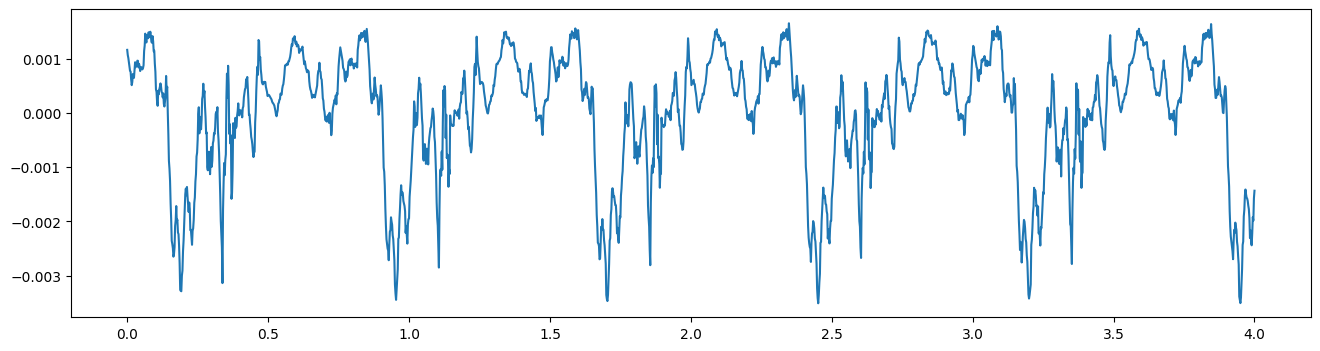

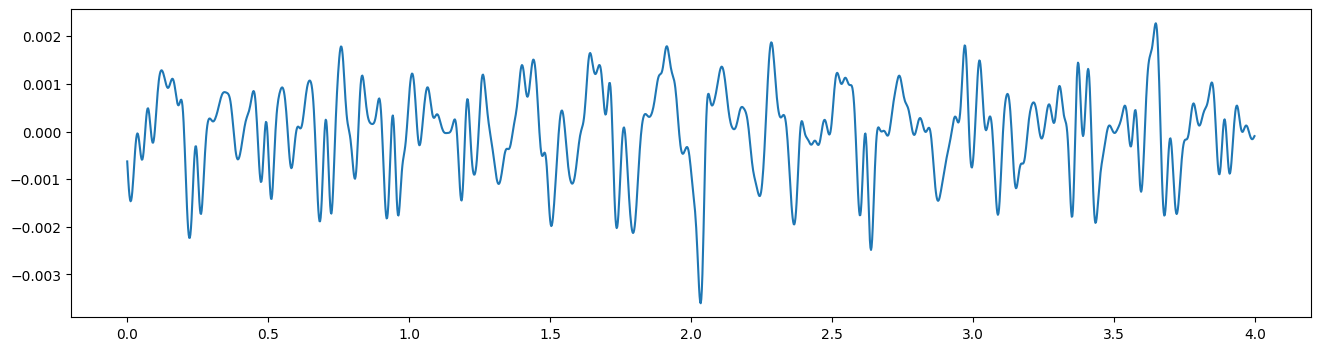

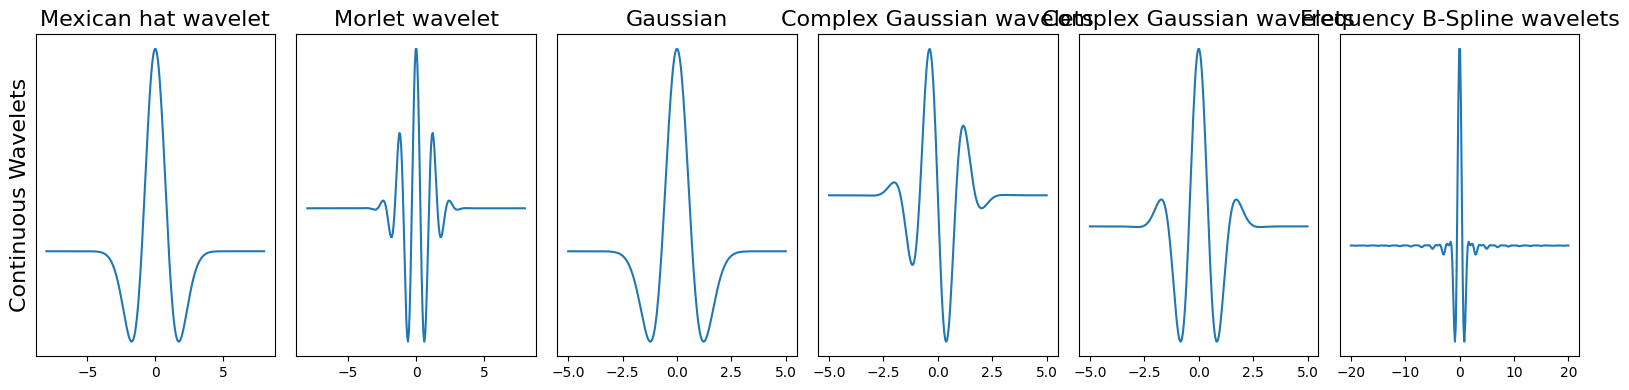

In [75]:
plt.figure(figsize=(16,4))
plt.plot(t_s, signal_s)

plt.figure(figsize=(16,4))
plt.plot(t_c, signal_c)

continuous_wavelets = ['mexh', 'morl', 'gaus2', 'cgau5', 'cgau4', 'fbsp']

list_list_wavelets = [continuous_wavelets]
list_funcs = [pywt.ContinuousWavelet]

fig, axarr = plt.subplots(nrows=1, ncols=6, figsize=(16,4))
for ii, list_wavelets in enumerate(list_list_wavelets):
    func = list_funcs[ii]
    row_no = ii
    for col_no, waveletname in enumerate(list_wavelets):
        wavelet = func(waveletname)
        family_name = wavelet.family_name
        biorthogonal = wavelet.biorthogonal
        orthogonal = wavelet.orthogonal
        symmetry = wavelet.symmetry
        if ii == 0:
            _ = wavelet.wavefun()
            wavelet_function = _[0]
            x_values = _[-1]
        else:
            wavelet_function, x_values = wavelet.wavefun()
        if col_no == 0:
            axarr[col_no].set_ylabel("Continuous Wavelets", fontsize=16)

        axarr[col_no].set_title("{}".format(family_name), fontsize=16)
        axarr[col_no].plot(x_values, wavelet_function)
        axarr[col_no].set_yticks([])
        axarr[col_no].set_yticklabels([])

plt.tight_layout()
plt.show()

[-19.93156857 -19.02843745 -18.12530632 -17.2221752  -16.31904408
 -15.41591295 -14.51278183 -13.60965071 -12.70651958 -11.80338846]
[-19.93156857 -19.13195139 -18.33233421 -17.53271702 -16.73309984
 -15.93348266 -15.13386548 -14.3342483  -13.53463111 -12.73501393]
[-19.93156857 -19.10436133 -18.27715408 -17.44994684 -16.6227396
 -15.79553236 -14.96832512 -14.14111787 -13.31391063 -12.48670339]
[-19.93156857 -19.18245171 -18.43333486 -17.68421801 -16.93510115
 -16.1859843  -15.43686744 -14.68775059 -13.93863373 -13.18951688]
[-19.93156857 -19.17545157 -18.41933457 -17.66321757 -16.90710058
 -16.15098358 -15.39486658 -14.63874958 -13.88263258 -13.12651559]
[-19.93156857 -19.09719345 -18.26281834 -17.42844323 -16.59406811
 -15.759693   -14.92531788 -14.09094277 -13.25656765 -12.42219254]


/home/alumnos/mburgosc/anaconda3/envs/my_env/lib/python3.10/site-packages/pywt/_cwt.py:117: FutureWarning: Wavelets of family fbsp, without parameters specified in the name are deprecated.  The name should follow the format fbspM-B-C where M is the spline order and B, C are floats representing the bandwidth frequency and center frequency, respectively (example, for backward compatibility: fbsp = fbsp2-1.0-0.5).
  wavelet = DiscreteContinuousWavelet(wavelet)


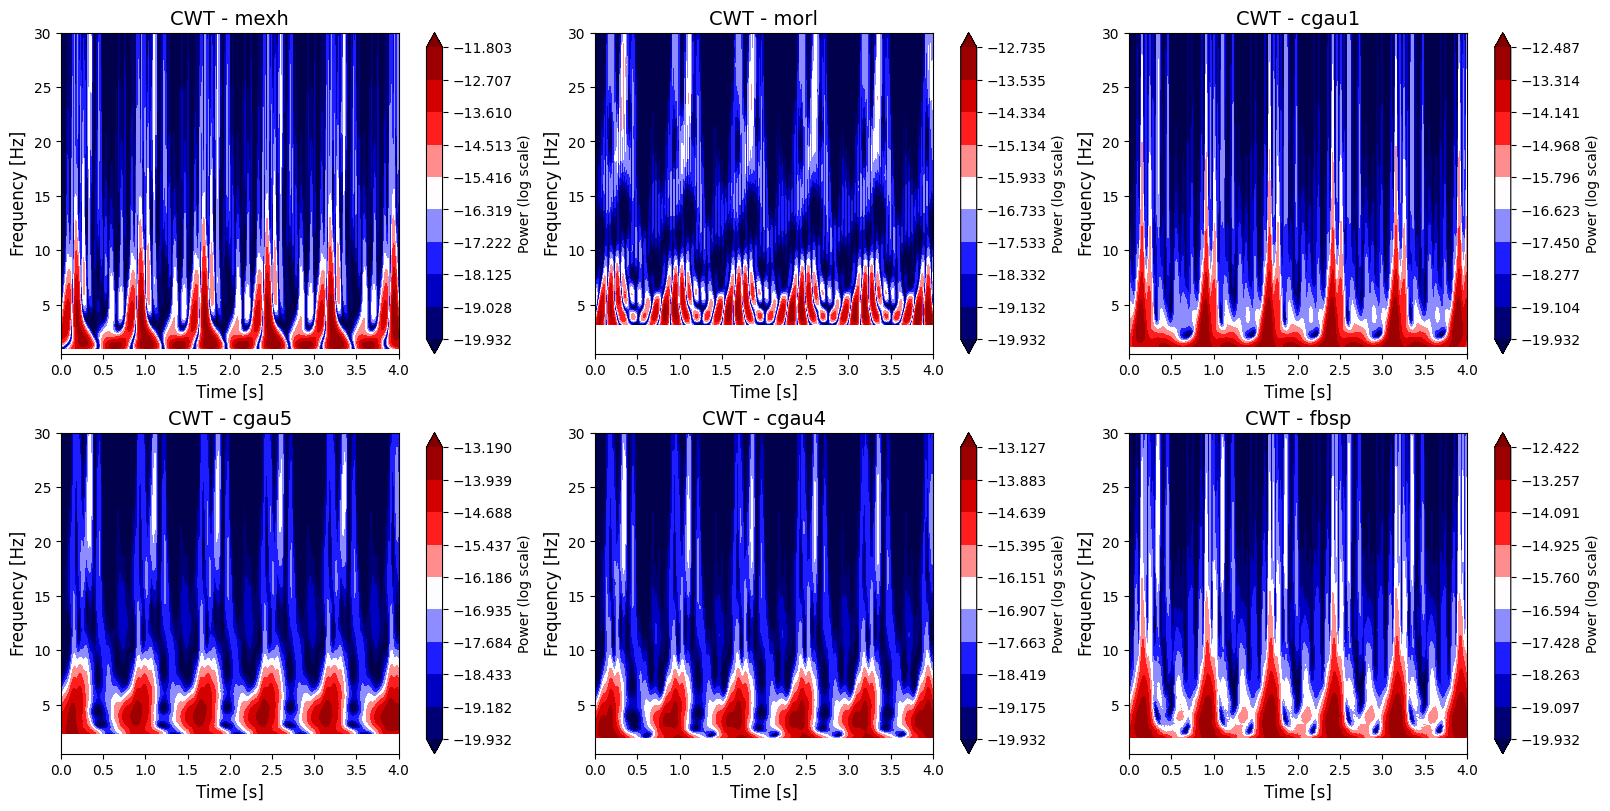

In [76]:
# ['cgau1', 'cgau2', 'cgau3', 'cgau4', 'cgau5', 'cgau6', 'cgau7', 'cgau8', 'cmor', 'fbsp', 'gaus1', 'gaus2', 'gaus3', 'gaus4', 'gaus5', 'gaus6', 'gaus7', 'gaus8', 'mexh', 'morl', 'shan']
continuous_wavelets = ['mexh', 'morl', 'cgau1', 'cgau5', 'cgau4', 'fbsp']
t_s = np.arange(len(signal_s)) / fs  # Vector de tiempo
scales = np.arange(1, 128)  # Escalas de la CWT

fig, axarr = plt.subplots(nrows=2, ncols=3, figsize=(16, 8), constrained_layout=True)

axarr = axarr.flatten()  # Convertir la matriz 2x3 en una lista de 6 ejes

for i, wavelets_fam in enumerate(continuous_wavelets):
    waveletname = wavelets_fam
    ax = axarr[i]  # Acceder al eje correcto
    im, coefficients, frequencies = plot_my_wavelet(ax, t_s, signal_s, scales, waveletname=waveletname, 
                         title=f'CWT - {waveletname}', ylabel='Frequency [Hz]', xlabel='Time [s]')
    
    fig.colorbar(im, ax=ax, label='Power (log scale)')  # Agregar barra de color

plt.show()




/home/alumnos/mburgosc/anaconda3/envs/my_env/lib/python3.10/site-packages/pywt/_cwt.py:117: FutureWarning: Wavelets from the family cmor, without parameters specified in the name are deprecated. The name should follow the format cmorB-C, where B and C are floats representing the bandwidth frequency and center frequency, respectively (example, for backward compatibility: cmor = cmor1.0-0.5).
  wavelet = DiscreteContinuousWavelet(wavelet)


[-19.93156857 -19.26870789 -18.60584722 -17.94298654 -17.28012586
 -16.61726519 -15.95440451 -15.29154383 -14.62868316 -13.96582248]


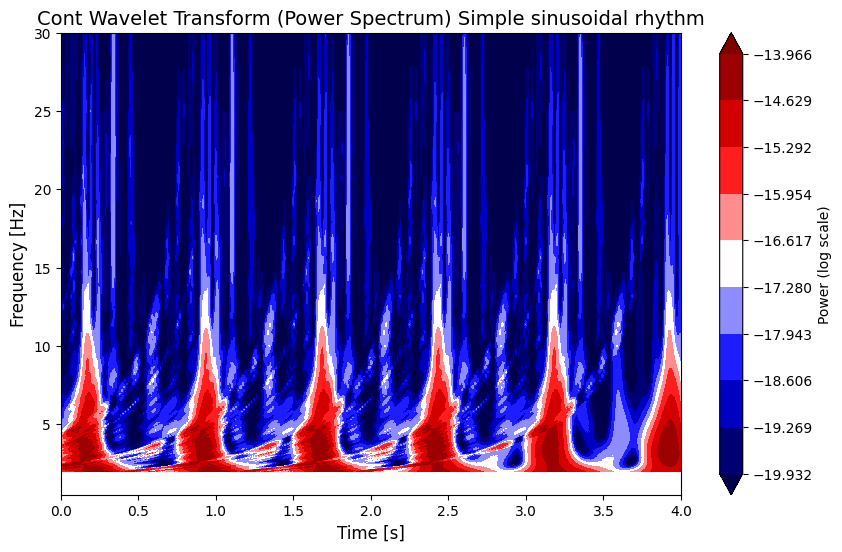

In [ ]:
t = np.arange(len(signal_s))/fs
scales = np.arange(1, 128)
fig, ax = plt.subplots(figsize=(10, 6)) 
plot_my_wavelet(ax, t_s, signal_s, scales, waveletname='cmor', title='Cont Wavelet Transform (Power Spectrum) Simple sinusoidal rhythm', ylabel='Frequency [Hz]', xlabel='Time [s]')

plt.colorbar(ax.collections[-1], ax=ax, label='Power (log scale)')  # Agregar barra de color
plt.show()

[-19.93156857 -19.26870789 -18.60584722 -17.94298654 -17.28012586
 -16.61726519 -15.95440451 -15.29154383 -14.62868316 -13.96582248]


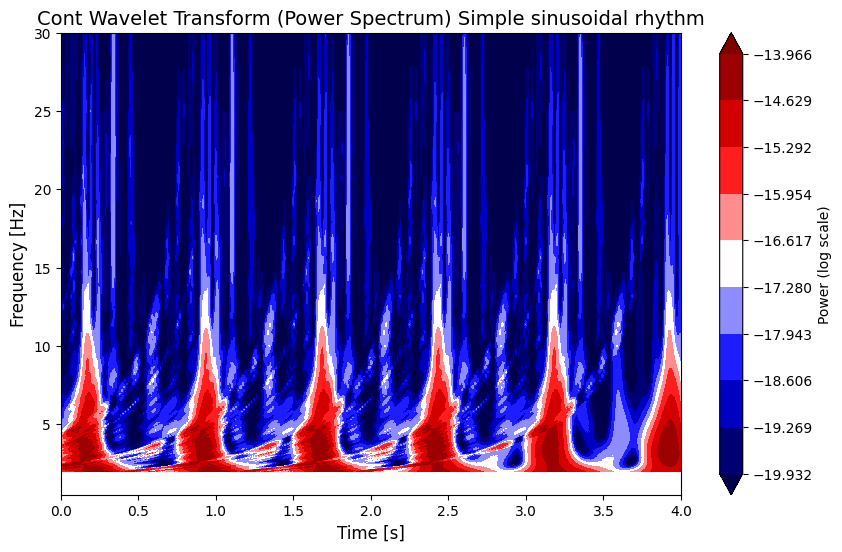

Coefficients shape: (127, 2001)
Frequencies: (127,)


In [136]:
# Asegúrate de que la función 'plot_my_wavelet' esté definida como en el código anterior
# Modificada para devolver los coeficientes y frecuencias

# Crear la figura y el eje
fig, ax = plt.subplots(figsize=(10, 6))

# Llamar a la función para graficar la CWT
im_s, coefficients_s, frequencies_s = plot_my_wavelet(
    ax, 
    t_s, 
    signal_s, 
    scales, 
    waveletname='cmor', 
    title='Cont Wavelet Transform (Power Spectrum) Simple sinusoidal rhythm', 
    ylabel='Frequency [Hz]', 
    xlabel='Time [s]'
)

# Mostrar la barra de color
plt.colorbar(im_s, ax=ax, label='Power (log scale)')

# Mostrar el gráfico
plt.show()

# Los coeficientes y frecuencias están disponibles
print("Coefficients shape:", coefficients_s.shape)  # Dimensiones de los coeficientes
print("Frequencies:", frequencies_s.shape)  # Las frecuencias correspondientes a las escalas


[-19.93156857 -19.29755668 -18.66354479 -18.02953291 -17.39552102
 -16.76150913 -16.12749724 -15.49348535 -14.85947347 -14.22546158]


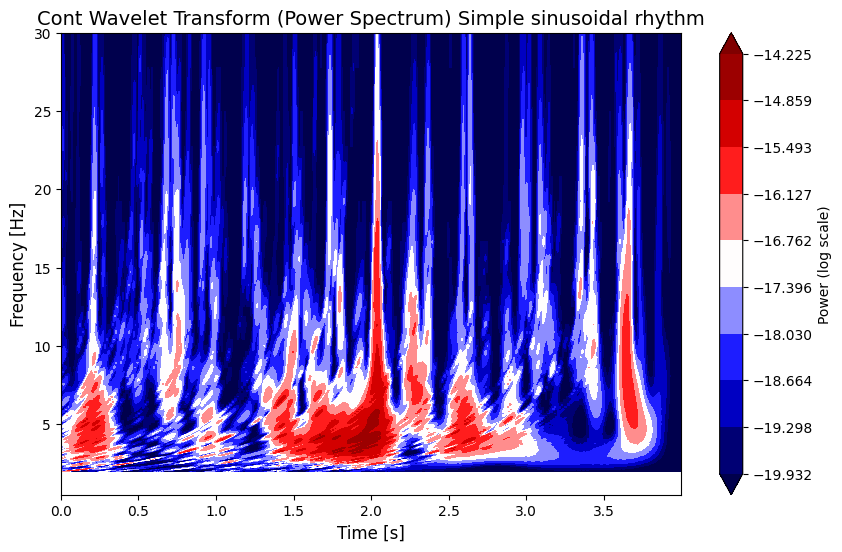

Coefficients shape: (127, 2000)
Frequencies: (127,)


In [137]:
# Asegúrate de que la función 'plot_my_wavelet' esté definida como en el código anterior
# Modificada para devolver los coeficientes y frecuencias

# Crear la figura y el eje
fig, ax = plt.subplots(figsize=(10, 6))

# Llamar a la función para graficar la CWT
im_c, coefficients_c, frequencies_c = plot_my_wavelet(
    ax, 
    t_c, 
    signal_c, 
    scales, 
    waveletname='cmor', 
    title='Cont Wavelet Transform (Power Spectrum) Simple sinusoidal rhythm', 
    ylabel='Frequency [Hz]', 
    xlabel='Time [s]'
)

# Mostrar la barra de color
plt.colorbar(im_c, ax=ax, label='Power (log scale)')

# Mostrar el gráfico
plt.show()

# Los coeficientes y frecuencias están disponibles
print("Coefficients shape:", coefficients_c.shape)  # Dimensiones de los coeficientes
print("Frequencies:", frequencies_c.shape)  # Las frecuencias correspondientes a las escalas


Frecuencias (Hz) correspondientes a cada escala: [250.         125.          83.33333333  62.5         50.
  41.66666667  35.71428571  31.25        27.77777778  25.
  22.72727273  20.83333333  19.23076923  17.85714286  16.66666667
  15.625       14.70588235  13.88888889  13.15789474  12.5
  11.9047619   11.36363636  10.86956522  10.41666667  10.
   9.61538462   9.25925926   8.92857143   8.62068966   8.33333333
   8.06451613   7.8125       7.57575758   7.35294118   7.14285714
   6.94444444   6.75675676   6.57894737   6.41025641   6.25
   6.09756098   5.95238095   5.81395349   5.68181818   5.55555556
   5.43478261   5.31914894   5.20833333   5.10204082   5.
   4.90196078   4.80769231   4.71698113   4.62962963   4.54545455
   4.46428571   4.38596491   4.31034483   4.23728814   4.16666667
   4.09836066   4.03225806   3.96825397   3.90625      3.84615385
   3.78787879   3.73134328   3.67647059   3.62318841   3.57142857
   3.52112676   3.47222222   3.42465753   3.37837838   3.33333333
   3.2

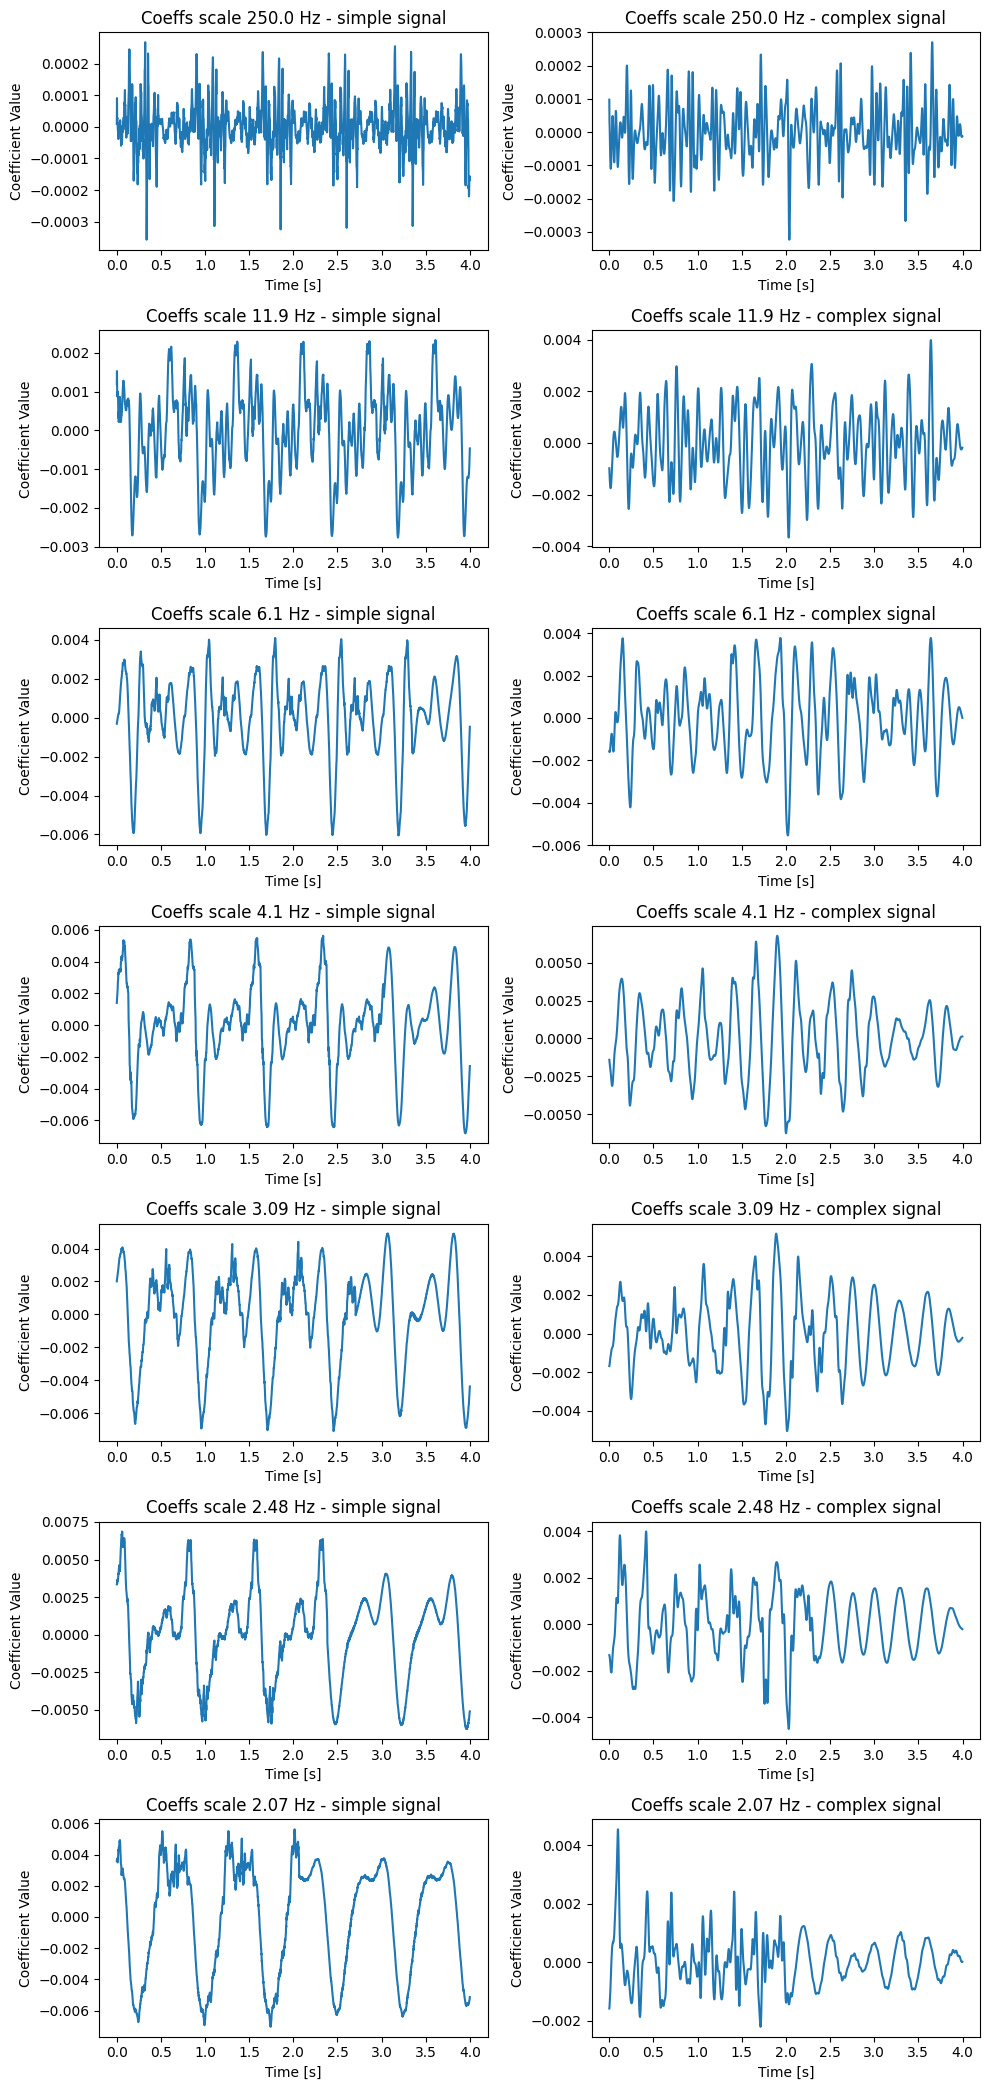

In [138]:
import matplotlib.pyplot as plt

print(f"Frecuencias (Hz) correspondientes a cada escala: {frequencies_s}")
frequencies_s = frequencies_s.tolist()
frequencies_c = frequencies_c.tolist()

# Seleccionar las escalas de 20 en 20 (por ejemplo, las escalas en los índices 0, 20, 40, ..., 120)
indices = list(range(0, len(frequencies_s), 20))

# Crear la figura y los subgráficos (7 filas y 2 columnas)
fig, axes = plt.subplots(nrows=len(indices), ncols=2, figsize=(10, len(indices)*3))  # Acomodar según el número de escalas seleccionadas

# Flatten el arreglo de ejes para facilitar el acceso
axes = axes.flatten()

# Graficar los coeficientes para cada frecuencia y para las dos señales
for i, idx in enumerate(indices):
    ax1 = axes[i * 2]  # Primer gráfico (columna 1, fila i)
    ax2 = axes[i * 2 + 1]  # Segundo gráfico (columna 2, fila i)

    # Graficar para la primera señal (coeficientes_s)
    ax1.plot(t_s, coefficients_s[idx, :])
    ax1.set_title(f"Coeffs scale {round(frequencies_s[idx], 2)} Hz - simple signal")
    ax1.set_xlabel("Time [s]")
    ax1.set_ylabel("Coefficient Value")

    # Graficar para la segunda señal (coeficientes_c)
    ax2.plot(t_c, coefficients_c[idx, :])
    ax2.set_title(f"Coeffs scale {round(frequencies_c[idx], 2)} Hz - complex signal")
    ax2.set_xlabel("Time [s]")
    ax2.set_ylabel("Coefficient Value")

# Ajustar el espaciado entre las subgráficas
plt.tight_layout()

# Mostrar el gráfico
plt.show()


[-19.93156857 -19.13195139 -18.33233421 -17.53271702 -16.73309984
 -15.93348266 -15.13386548 -14.3342483  -13.53463111 -12.73501393]


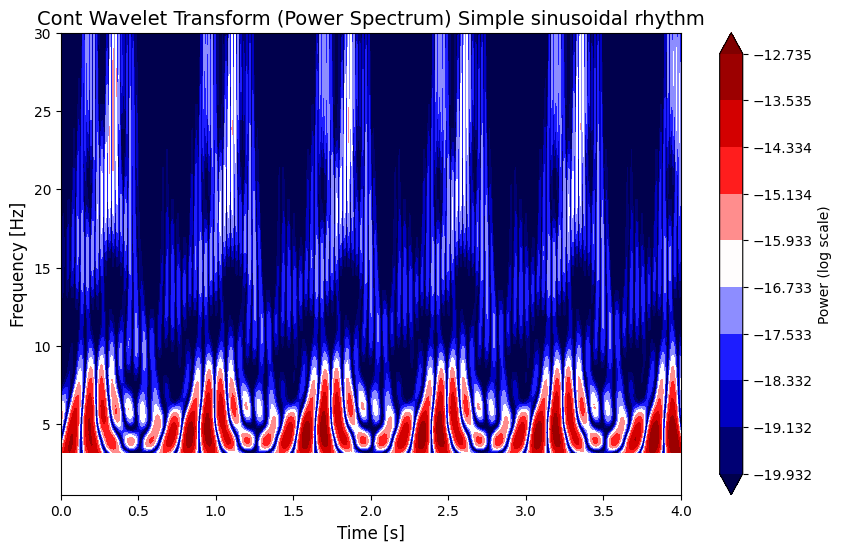

In [43]:
t = np.arange(len(signal_s))/fs
scales = np.arange(1, 128)
fig, ax = plt.subplots(figsize=(10, 6)) 
plot_my_wavelet(ax, t_s, signal_s, scales, waveletname='morl', title='Cont Wavelet Transform (Power Spectrum) Simple sinusoidal rhythm', ylabel='Frequency [Hz]', xlabel='Time [s]')

plt.colorbar(ax.collections[-1], ax=ax, label='Power (log scale)')  # Agregar barra de color
plt.show()

[-19.93156857 -19.29755668 -18.66354479 -18.02953291 -17.39552102
 -16.76150913 -16.12749724 -15.49348535 -14.85947347 -14.22546158]


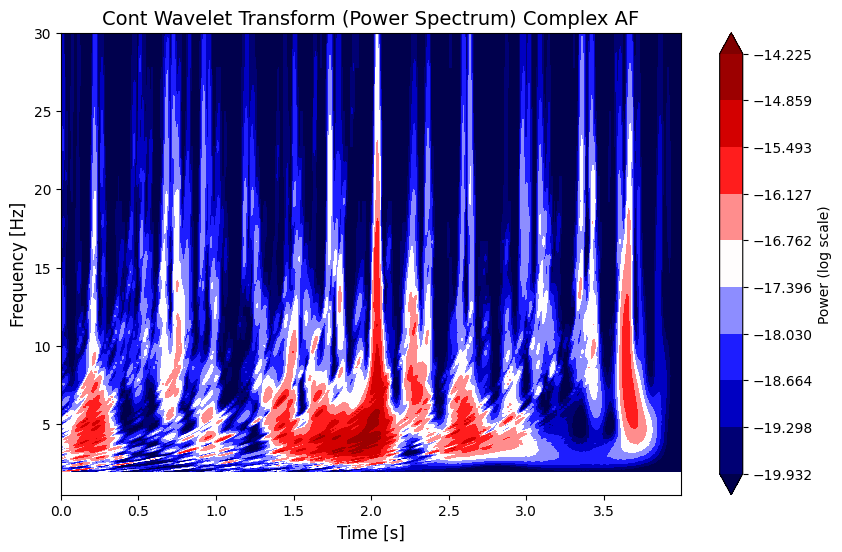

In [44]:
fig, ax = plt.subplots(figsize=(10, 6)) 
plot_my_wavelet(ax, t_c, signal_c, scales, title='Cont Wavelet Transform (Power Spectrum) Complex AF', ylabel='Frequency [Hz]', xlabel='Time [s]')

plt.colorbar(ax.collections[-1], ax=ax, label='Power (log scale)')  # Agregar barra de color
plt.show()

[-19.93156857 -19.04279991 -18.15403125 -17.26526259 -16.37649394
 -15.48772528 -14.59895662 -13.71018796 -12.8214193  -11.93265064]


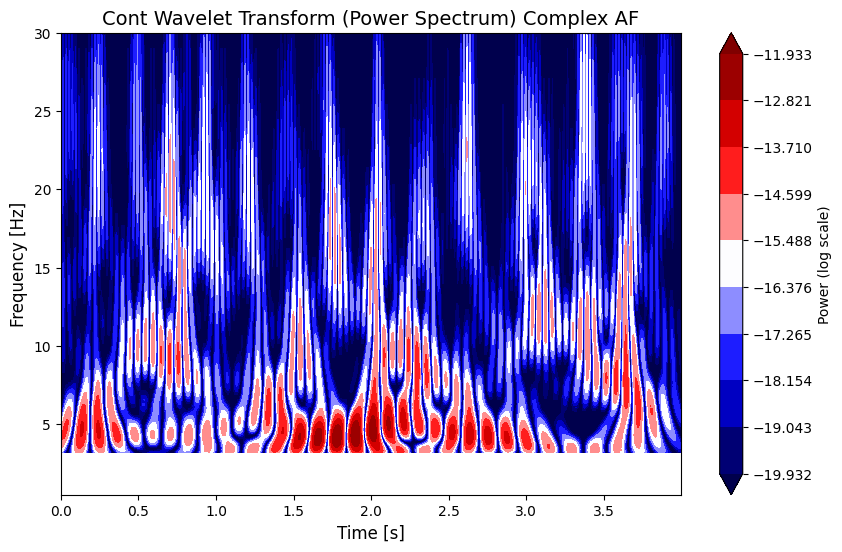

In [45]:
fig, ax = plt.subplots(figsize=(10, 6)) 
plot_my_wavelet(ax, t_c, signal_c, scales, waveletname='morl', title='Cont Wavelet Transform (Power Spectrum) Complex AF', ylabel='Frequency [Hz]', xlabel='Time [s]')

plt.colorbar(ax.collections[-1], ax=ax, label='Power (log scale)')  # Agregar barra de color
plt.show()

[-19.93156857 -19.02843745 -18.12530632 -17.2221752  -16.31904408
 -15.41591295 -14.51278183 -13.60965071 -12.70651958 -11.80338846]


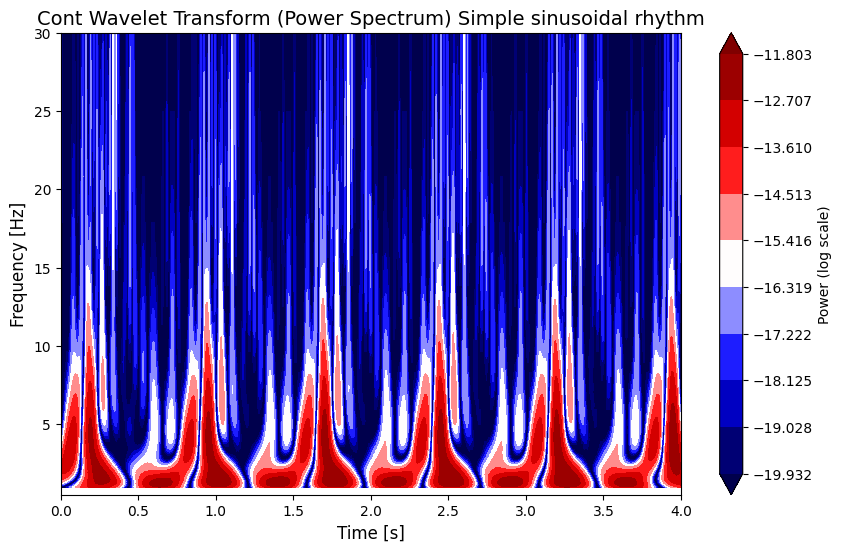

In [47]:
t = np.arange(len(signal_s))/fs
scales = np.arange(1, 128)
fig, ax = plt.subplots(figsize=(10, 6)) 
plot_my_wavelet(ax, t_s, signal_s, scales, waveletname='mexh', title='Cont Wavelet Transform (Power Spectrum) Simple sinusoidal rhythm', ylabel='Frequency [Hz]', xlabel='Time [s]')

plt.colorbar(ax.collections[-1], ax=ax, label='Power (log scale)')  # Agregar barra de color
plt.show()

[-19.93156857 -19.09169066 -18.25181275 -17.41193484 -16.57205694
 -15.73217903 -14.89230112 -14.05242321 -13.2125453  -12.37266739]


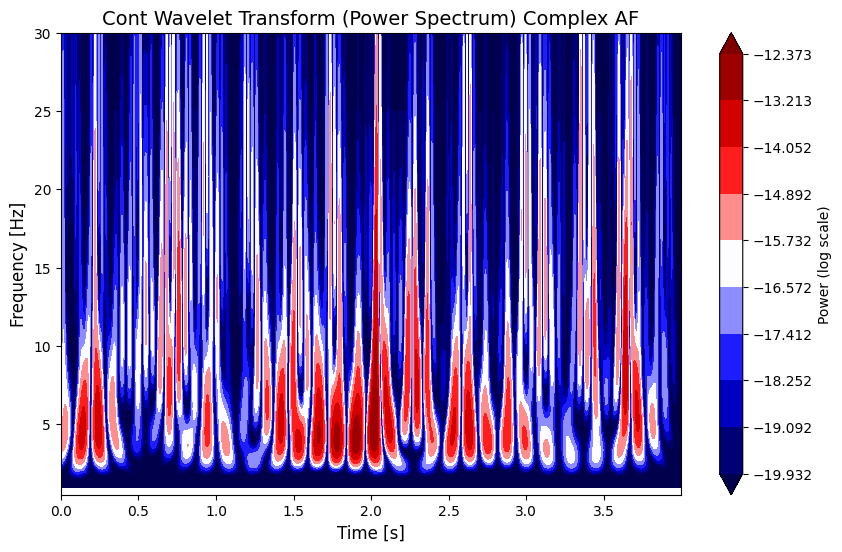

In [49]:
fig, ax = plt.subplots(figsize=(10, 6)) 
plot_my_wavelet(ax, t_c, signal_c, scales, waveletname='mexh', title='Cont Wavelet Transform (Power Spectrum) Complex AF', ylabel='Frequency [Hz]', xlabel='Time [s]')

plt.colorbar(ax.collections[-1], ax=ax, label='Power (log scale)')  # Agregar barra de color
plt.show()

Correlación entre FFT y CWT: 0.6505
Distancia Euclidiana: 0.9423


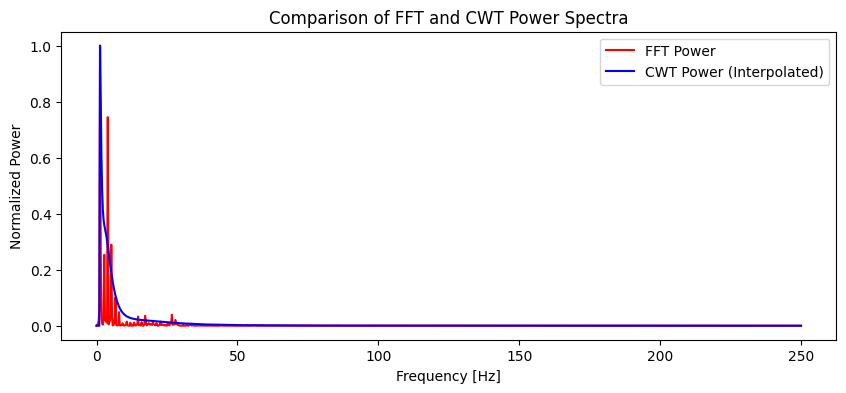

In [69]:
import numpy as np
import pywt
from scipy.interpolate import interp1d
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# Suponiendo que ya tienes 'signal_s' y 'fs' (frecuencia de muestreo)
fs = 500
# ---- 1. Calcular la FFT ----
n = len(signal_s)
freqs_s = np.fft.rfftfreq(n, d=1/fs)  # Frecuencias de la FFT
fft_power_s = np.abs(np.fft.rfft(signal_s))**2  # Espectro de potencia

# ---- 2. Calcular la CWT ----
scales = np.arange(1, 128)  # Escalas de la CWT
dt = 1/fs
coefficients_s, frequencies_s = pywt.cwt(signal_s, scales, 'gaus2', dt)  # Puedes cambiar la wavelet
cwt_power_s = np.abs(coefficients_s) ** 2  # Potencia

# ---- 3. Promediar la CWT en el tiempo ----
cwt_avg_power_s = np.mean(cwt_power_s, axis=1)  # Promedio sobre el eje del tiempo

# ---- 4. Interpolar la CWT para coincidir con la FFT ----
interp_func_s = interp1d(frequencies_s, cwt_avg_power_s, kind='linear', bounds_error=False, fill_value=0)
cwt_interp_power_s = interp_func_s(freqs_s)  # Valores de la CWT en las mismas frecuencias de la FFT

# ---- 5. Calcular la similitud ----
corr, _ = pearsonr(fft_power_s, cwt_interp_power_s)  # Correlación de Pearson
dist_euc = np.linalg.norm(fft_power_s - cwt_interp_power_s)  # Distancia Euclidiana

print(f"Correlación entre FFT y CWT: {corr:.4f}")
print(f"Distancia Euclidiana: {dist_euc:.4f}")

# ---- 6. Graficar comparación ----
plt.figure(figsize=(10, 4))
plt.plot(freqs_s, fft_power_s / np.max(fft_power_s), label="FFT Power", color="red")
plt.plot(freqs_s, cwt_interp_power_s / np.max(cwt_interp_power_s), label="CWT Power (Interpolated)", color="blue")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Normalized Power")
plt.legend()
plt.title("Comparison of FFT and CWT Power Spectra")
plt.show()


[-19.93156857 -19.02827135 -18.12497413 -17.22167691 -16.3183797
 -15.41508248 -14.51178526 -13.60848804 -12.70519082 -11.8018936 ]


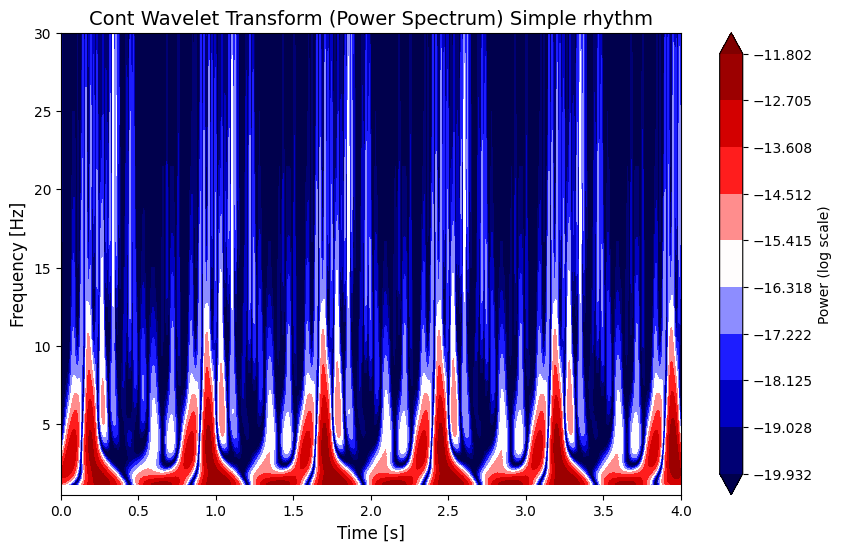

In [70]:
fig, ax = plt.subplots(figsize=(10, 6)) 
plot_my_wavelet(ax, t_s, signal_s, scales, waveletname='gaus2', title='Cont Wavelet Transform (Power Spectrum) Simple rhythm', ylabel='Frequency [Hz]', xlabel='Time [s]')

plt.colorbar(ax.collections[-1], ax=ax, label='Power (log scale)')  # Agregar barra de color
plt.show()

Correlación entre FFT y CWT: 0.7399
Distancia Euclidiana: 0.3324


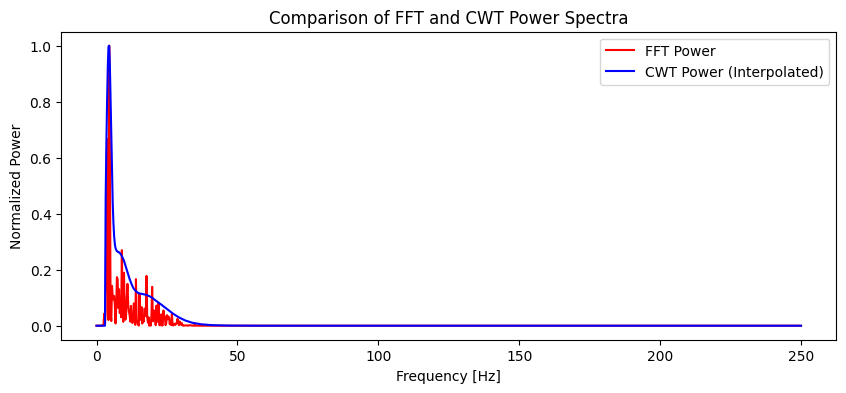

In [68]:
import numpy as np
import pywt
from scipy.interpolate import interp1d
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# Suponiendo que ya tienes 'signal_c' y 'fs' (frecuencia de muestreo)
fs = 500
# ---- 1. Calcular la FFT ----
n = len(signal_c)
freqs_c = np.fft.rfftfreq(n, d=1/fs)  # Frecuencias de la FFT
fft_power_c = np.abs(np.fft.rfft(signal_c))**2  # Espectro de potencia

# ---- 2. Calcular la CWT ----
scales = np.arange(1, 128)  # Escalas de la CWT
dt = 1/fs
coefficients_c, frequencies_c = pywt.cwt(signal_c, scales, 'morl', dt)  # Puedes cambiar la wavelet
cwt_power_c = np.abs(coefficients_c) ** 2  # Potencia

# ---- 3. Promediar la CWT en el tiempo ----
cwt_avg_power_c = np.mean(cwt_power_c, axis=1)  # Promedio sobre el eje del tiempo

# ---- 4. Interpolar la CWT para coincidir con la FFT ----
interp_func_c = interp1d(frequencies_c, cwt_avg_power_c, kind='linear', bounds_error=False, fill_value=0)
cwt_interp_power_c = interp_func_c(freqs_c)  # Valores de la CWT en las mismas frecuencias de la FFT

# ---- 5. Calcular la similitud ----
corr, _ = pearsonr(fft_power_c, cwt_interp_power_c)  # Correlación de Pearson
dist_euc = np.linalg.norm(fft_power_c - cwt_interp_power_c)  # Distancia Euclidiana

print(f"Correlación entre FFT y CWT: {corr:.4f}")
print(f"Distancia Euclidiana: {dist_euc:.4f}")

# ---- 6. Graficar comparación ----
plt.figure(figsize=(10, 4))
plt.plot(freqs_c, fft_power_c / np.max(fft_power_c), label="FFT Power", color="red")
plt.plot(freqs_c, cwt_interp_power_c / np.max(cwt_interp_power_c), label="CWT Power (Interpolated)", color="blue")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Normalized Power")
plt.legend()
plt.title("Comparison of FFT and CWT Power Spectra")
plt.show()


[-19.93156857 -19.04279991 -18.15403125 -17.26526259 -16.37649394
 -15.48772528 -14.59895662 -13.71018796 -12.8214193  -11.93265064]


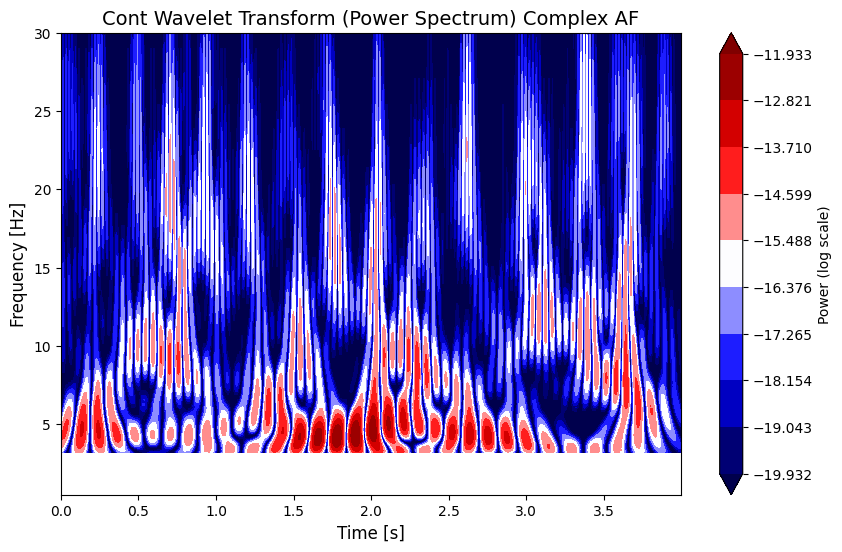

In [71]:
fig, ax = plt.subplots(figsize=(10, 6)) 
plot_my_wavelet(ax, t_c, signal_c, scales, waveletname='morl', title='Cont Wavelet Transform (Power Spectrum) Complex AF', ylabel='Frequency [Hz]', xlabel='Time [s]')

plt.colorbar(ax.collections[-1], ax=ax, label='Power (log scale)')  # Agregar barra de color
plt.show()

In [66]:
wavelets = ['cgau1', 'cgau2', 'cgau3', 'cgau4', 'cgau5', 'cgau6', 'cgau7', 'cgau8', 'cmor1.0-0.5', 'fbsp2-1.0-0.5', 'gaus1', 'gaus2', 'gaus3', 'gaus4', 'gaus5', 'gaus6', 'gaus7', 'gaus8', 'mexh', 'morl', 'shan']

results_s = []

for wavelet in wavelets:
    coefficients, frequencies = pywt.cwt(signal_s, scales, wavelet, dt)
    cwt_power = np.abs(coefficients) ** 2
    cwt_avg_power = np.mean(cwt_power, axis=1)

    interp_func = interp1d(frequencies, cwt_avg_power, kind='linear', bounds_error=False, fill_value=0)
    cwt_interp_power = interp_func(freqs)

    corr, _ = pearsonr(fft_power_s, cwt_interp_power)
    dist_euc = np.linalg.norm(fft_power_s - cwt_interp_power)

    results_s.append((wavelet, corr, dist_euc))

    # ---- 6. Graficar comparación ----
    #plt.figure(figsize=(10, 4))
    #plt.plot(freqs, fft_power / np.max(fft_power), label="FFT Power", color="red")
    #plt.plot(freqs, cwt_interp_power / np.max(cwt_interp_power), label="CWT Power (Interpolated)", color="blue")
    #plt.xlabel("Frequency [Hz]")
    #plt.ylabel("Normalized Power")
    #plt.legend()
    #plt.title(f"Comparison of FFT and CWT Power Spectra {wavelet}")
    #plt.show()
# Ordenar por mejor correlación
results_s.sort(key=lambda x: -x[1])

# Mostrar mejores wavelets
for wavelet, corr, dist in results_s:
    print(f"Wavelet: {wavelet} | Correlación: {corr:.4f} | Distancia Euclidiana: {dist:.4f}")

# --> gaus2

Wavelet: gaus2 | Correlación: 0.6505 | Distancia Euclidiana: 0.9423
Wavelet: cgau1 | Correlación: 0.6126 | Distancia Euclidiana: 0.9423
Wavelet: mexh | Correlación: 0.5878 | Distancia Euclidiana: 0.9423
Wavelet: gaus1 | Correlación: 0.5511 | Distancia Euclidiana: 0.9423
Wavelet: gaus7 | Correlación: 0.3044 | Distancia Euclidiana: 0.9424
Wavelet: gaus8 | Correlación: 0.3033 | Distancia Euclidiana: 0.9424
Wavelet: cgau6 | Correlación: 0.3020 | Distancia Euclidiana: 0.9424
Wavelet: cgau5 | Correlación: 0.3007 | Distancia Euclidiana: 0.9424
Wavelet: gaus6 | Correlación: 0.2960 | Distancia Euclidiana: 0.9424
Wavelet: morl | Correlación: 0.2947 | Distancia Euclidiana: 0.9424
Wavelet: shan | Correlación: 0.2885 | Distancia Euclidiana: 0.9424
Wavelet: cgau8 | Correlación: 0.2783 | Distancia Euclidiana: 0.9424
Wavelet: cgau7 | Correlación: 0.2766 | Distancia Euclidiana: 0.9424
Wavelet: cgau4 | Correlación: 0.2761 | Distancia Euclidiana: 0.9424
Wavelet: gaus5 | Correlación: 0.2751 | Distancia Eu

In [67]:
wavelets = ['cgau1', 'cgau2', 'cgau3', 'cgau4', 'cgau5', 'cgau6', 'cgau7', 'cgau8', 'cmor', 'fbsp', 'gaus1', 'gaus2', 'gaus3', 'gaus4', 'gaus5', 'gaus6', 'gaus7', 'gaus8', 'mexh', 'morl', 'shan']

results_c = []

for wavelet in wavelets:
    coefficients, frequencies = pywt.cwt(signal_c, scales, wavelet, dt)
    cwt_power = np.abs(coefficients) ** 2
    cwt_avg_power = np.mean(cwt_power, axis=1)

    interp_func = interp1d(frequencies, cwt_avg_power, kind='linear', bounds_error=False, fill_value=0)
    cwt_interp_power = interp_func(freqs)

    corr, _ = pearsonr(fft_power_c, cwt_interp_power)
    dist_euc = np.linalg.norm(fft_power_c - cwt_interp_power)

    results_c.append((wavelet, corr, dist_euc))

    # ---- 6. Graficar comparación ----
    #plt.figure(figsize=(10, 4))
    #plt.plot(freqs, fft_power / np.max(fft_power), label="FFT Power", color="red")
    #plt.plot(freqs, cwt_interp_power / np.max(cwt_interp_power), label="CWT Power (Interpolated)", color="blue")
    #plt.xlabel("Frequency [Hz]")
    #plt.ylabel("Normalized Power")
    #plt.legend()
    #plt.title(f"Comparison of FFT and CWT Power Spectra {wavelet}")
    #plt.show()
# Ordenar por mejor correlación
results_c.sort(key=lambda x: -x[1])

# Mostrar mejores wavelets
for wavelet, corr, dist in results_c:
    print(f"Wavelet: {wavelet} | Correlación: {corr:.4f} | Distancia Euclidiana: {dist:.4f}")

# --> gaus8

Wavelet: morl | Correlación: 0.7399 | Distancia Euclidiana: 0.3324
Wavelet: cgau8 | Correlación: 0.7318 | Distancia Euclidiana: 0.3324
Wavelet: cgau7 | Correlación: 0.7239 | Distancia Euclidiana: 0.3324
Wavelet: gaus7 | Correlación: 0.7230 | Distancia Euclidiana: 0.3324
Wavelet: gaus8 | Correlación: 0.7207 | Distancia Euclidiana: 0.3324
Wavelet: cgau6 | Correlación: 0.7163 | Distancia Euclidiana: 0.3324
Wavelet: cgau5 | Correlación: 0.7151 | Distancia Euclidiana: 0.3324
Wavelet: gaus5 | Correlación: 0.7096 | Distancia Euclidiana: 0.3324
Wavelet: shan | Correlación: 0.7018 | Distancia Euclidiana: 0.3324
Wavelet: cgau4 | Correlación: 0.6981 | Distancia Euclidiana: 0.3324
Wavelet: gaus6 | Correlación: 0.6965 | Distancia Euclidiana: 0.3324
Wavelet: cgau3 | Correlación: 0.6913 | Distancia Euclidiana: 0.3324
Wavelet: gaus3 | Correlación: 0.6841 | Distancia Euclidiana: 0.3324
Wavelet: fbsp | Correlación: 0.6809 | Distancia Euclidiana: 0.3324
Wavelet: gaus4 | Correlación: 0.6783 | Distancia Eu